In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import tqdm
from IPython.display import clear_output
from scipy.stats import ks_2samp, wasserstein_distance
from scipy.spatial.distance import jensenshannon
from itertools import product
from pathlib import Path

%matplotlib inline

In [2]:

folder = "G:\Meu Drive\mestrado_final_files\simulations\\NGramModel_ExtraInfo_MultiTowers\\"
folder = "G:\Meu Drive\mestrado_final_files\simulations\\NGramModel_ExtraInfo\\"

In [3]:
dict_metricas_simulacao = {}

In [44]:
set_neural_network = "_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables2_parte"

lista_resultados = []
for season_str in ["201819", "201920", "202021", "202122", "202223"]:

    for file in [item for item in os.listdir(folder) if season_str in item and set_neural_network in item]:
        df_ = pd.read_parquet(folder + file)

        xdf = df_.query("period == 4").groupby("sim_id")[["home_points", "away_points"]].max()\
        .assign(outcome = "tie")\
        .assign(outcome = lambda df: np.where(df["home_points"] > df["away_points"], "home", df["outcome"]))\
        .assign(outcome = lambda df: np.where(df["home_points"] < df["away_points"], "away", df["outcome"]))\
        .assign(season = season_str)
        
        lista_resultados.append(xdf)

dict_metricas_simulacao["pontos_fim_4_periodo"] = pd.concat(lista_resultados)

In [63]:
lista_resultados = []
for season_str in ["201819", "201920", "202021", "202122", "202223"]:

    for file in [item for item in os.listdir(folder) if season_str in item and set_neural_network in item]:
        df_ = pd.read_parquet(folder + file)

        xdf = df_.groupby("sim_id")[["home_points", "away_points"]].max()\
        .assign(outcome = "tie")\
        .assign(outcome = lambda df: np.where(df["home_points"] > df["away_points"], "home", df["outcome"]))\
        .assign(outcome = lambda df: np.where(df["home_points"] < df["away_points"], "away", df["outcome"]))\
        .assign(season = season_str)
        
        lista_resultados.append(xdf)

dict_metricas_simulacao["pontos_fim"] = pd.concat(lista_resultados)

In [45]:
lista_props = [] 
for _ in range(1000):
    idx = random.sample(range(0, 10000), 1000)

    for season_str in ["201819", "201920", "202021", "202122", "202223"]:
#    idx = random.choices(range(1, 10000), k = 1000)
        lista_props.append(
            dict_metricas_simulacao["pontos_fim_4_periodo"].query("season == @season_str").iloc[idx]["outcome"].value_counts().reset_index().assign(season = season_str)
            )

In [52]:
pd.concat(lista_props)\
.assign(count = lambda df: 100 * df["count"] / 1000)\
.groupby(["outcome", "season"])["count"].describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count     mean       std   min      1%      5%    10%  \
outcome season                                                           
away    201819  1000.0  42.3955  1.417709  37.5  39.000  40.100  40.60   
        201920  1000.0  43.9626  1.509397  39.2  40.699  41.600  42.00   
        202021  1000.0  45.4549  1.564354  41.3  41.999  42.900  43.39   
        202122  1000.0  43.2087  1.506162  38.4  39.600  40.800  41.30   
        202223  1000.0  43.9042  1.482890  38.6  40.399  41.500  42.10   
home    201819  1000.0  55.0278  1.420664  50.1  51.700  52.695  53.20   
        201920  1000.0  53.5232  1.528679  49.0  50.099  51.000  51.50   
        202021  1000.0  51.8898  1.543735  46.9  48.300  49.300  49.90   
        202122  1000.0  54.5257  1.515297  49.4  50.899  52.100  52.60   
        202223  1000.0  53.1860  1.492887  48.2  49.700  50.800  51.30   
tie     201819  1000.0   2.5767  0.479935   1.2   1.599   1.800   1.90   
        201920  1000.0   2.5142  0.450134   1.1   1.500   1.800   2.00   
        202021  1000.0   2.6553  0.510855   1.1   1.600   1.800   2.00   
        202122  1000.0   2.2656  0.462916   0.6   1.300   1.500   1.70   
        202223  1000.0   2.9098  0.505192   1.5   1.899   2.100   2.30   

                   25%   50%     75%   90%   95%     99%   max  
outcome season                                                  
away    201819  41.500  42.4  43.300  44.2  44.8  45.800  46.9  
        201920  42.900  44.0  45.000  45.9  46.6  47.400  48.8  
        202021  44.300  45.5  46.500  47.5  48.1  49.100  50.1  
        202122  42.200  43.2  44.200  45.1  45.7  47.100  48.4  
        202223  42.900  43.9  45.000  45.7  46.3  47.400  48.7  
home    201819  54.075  55.1  55.925  56.9  57.4  58.300  59.6  
        201920  52.500  53.5  54.600  55.5  56.0  56.901  57.9  
        202021  50.875  51.9  53.000  54.0  54.4  55.000  56.4  
        202122  53.500  54.5  55.525  56.5  57.1  57.901  59.6  
        202223  52.200  53.2  54.200  55.1  55.7  56.601  58.6  
tie     201819   2.200   2.6   2.900   3.2   3.4   3.700   4.0  
        201920   2.200   2.5   2.800   3.1   3.3   3.600   4.2  
        202021   2.300   2.6   3.000   3.3   3.5   3.900   4.3  
        202122   2.000   2.2   2.600   2.9   3.0   3.401   3.8  
        202223   2.600   2.9   3.300   3.6   3.7   4.100   4.8

In [62]:
full_pbp_tokenized.query("period <= 4")\
.groupby(["season", "game_id"], as_index = False, dropna = False)[["hpts", "vpts"]].max()\
.assign(outcome = "tie")\
.assign(outcome = lambda df: np.where(df["hpts"] > df["vpts"], "home", df["outcome"]))\
.assign(outcome = lambda df: np.where(df["hpts"] < df["vpts"], "away", df["outcome"]))\
.groupby(["outcome", "season"], as_index = False, dropna = False).size()\
.assign(total = lambda df: df.groupby("season")["size"].transform("sum"))\
.assign(prop = lambda df: 100 * df["size"] / df["total"])\
.pivot_table(index = "season", columns = "outcome", values = "prop")

outcome,away,home,tie
season,,,
201819,38.490854,56.097561,5.411585
201920,42.344707,51.093613,6.561680
202021,42.649573,52.222222,5.128205
202122,42.857143,52.683296,4.459562
202223,39.090909,54.545455,6.363636
202324,42.530120,52.650602,4.819277


In [64]:
lista_props = [] 
for _ in range(1000):
    idx = random.sample(range(0, 10000), 1000)

    for season_str in ["201819", "201920", "202021", "202122", "202223"]:
#    idx = random.choices(range(1, 10000), k = 1000)
        lista_props.append(
            dict_metricas_simulacao["pontos_fim"].query("season == @season_str").iloc[idx]["outcome"].value_counts().reset_index().assign(season = season_str)
            )

In [65]:
pd.concat(lista_props)\
.assign(count = lambda df: 100 * df["count"] / 1000)\
.groupby(["outcome", "season"])["count"].describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count     mean       std   min      1%    5%    10%   25%  \
outcome season                                                               
away    201819  1000.0  43.5811  1.471101  38.6  40.199  41.1  41.79  42.6   
        201920  1000.0  45.1154  1.530714  39.7  41.899  42.6  43.10  44.1   
        202021  1000.0  46.5352  1.474719  42.1  43.000  44.0  44.60  45.6   
        202122  1000.0  44.2552  1.461372  38.4  40.900  41.8  42.40  43.3   
        202223  1000.0  45.3077  1.522790  40.6  41.900  42.9  43.39  44.3   
home    201819  1000.0  56.4189  1.471101  51.4  52.800  54.1  54.60  55.5   
        201920  1000.0  54.8846  1.530714  49.4  51.200  52.3  52.90  53.9   
        202021  1000.0  53.4648  1.474719  47.1  50.200  51.1  51.50  52.5   
        202122  1000.0  55.7448  1.461372  51.1  52.299  53.4  53.90  54.8   
        202223  1000.0  54.6923  1.522790  49.7  50.999  52.2  52.70  53.6   

                 50%   75%    90%   95%     99%   max  
outcome season                                         
away    201819  43.6  44.5  45.40  45.9  47.200  48.6  
        201920  45.1  46.1  47.10  47.7  48.800  50.6  
        202021  46.6  47.5  48.50  48.9  49.800  52.9  
        202122  44.3  45.2  46.10  46.6  47.701  48.9  
        202223  45.3  46.4  47.30  47.8  49.001  50.3  
home    201819  56.4  57.4  58.21  58.9  59.801  61.4  
        201920  54.9  55.9  56.90  57.4  58.101  60.3  
        202021  53.4  54.4  55.40  56.0  57.000  57.9  
        202122  55.7  56.7  57.60  58.2  59.100  61.6  
        202223  54.7  55.7  56.61  57.1  58.100  59.4

In [66]:
full_pbp_tokenized\
.groupby(["season", "game_id"], as_index = False, dropna = False)[["hpts", "vpts"]].max()\
.assign(outcome = "tie")\
.assign(outcome = lambda df: np.where(df["hpts"] > df["vpts"], "home", df["outcome"]))\
.assign(outcome = lambda df: np.where(df["hpts"] < df["vpts"], "away", df["outcome"]))\
.groupby(["outcome", "season"], as_index = False, dropna = False).size()\
.assign(total = lambda df: df.groupby("season")["size"].transform("sum"))\
.assign(prop = lambda df: 100 * df["size"] / df["total"])\
.pivot_table(index = "season", columns = "outcome", values = "prop")

outcome,away,home
season,,
201819,40.929878,59.070122
201920,45.319335,54.680665
202021,45.299145,54.700855
202122,45.200302,54.799698
202223,41.893939,58.106061
202324,43.975904,56.024096


In [67]:
lista_resultados = []
for season_str in ["201819", "201920", "202021", "202122", "202223"]:

    for file in [item for item in os.listdir(folder) if season_str in item and set_neural_network in item]:
        df_ = pd.read_parquet(folder + file)

        xdf = df_.query("period == 4").groupby("sim_id")[["home_points", "away_points"]].max()\
        .assign(season = season_str)
        
        lista_resultados.append(xdf)

dict_metricas_simulacao["pontos_dist"] = pd.concat(lista_resultados)

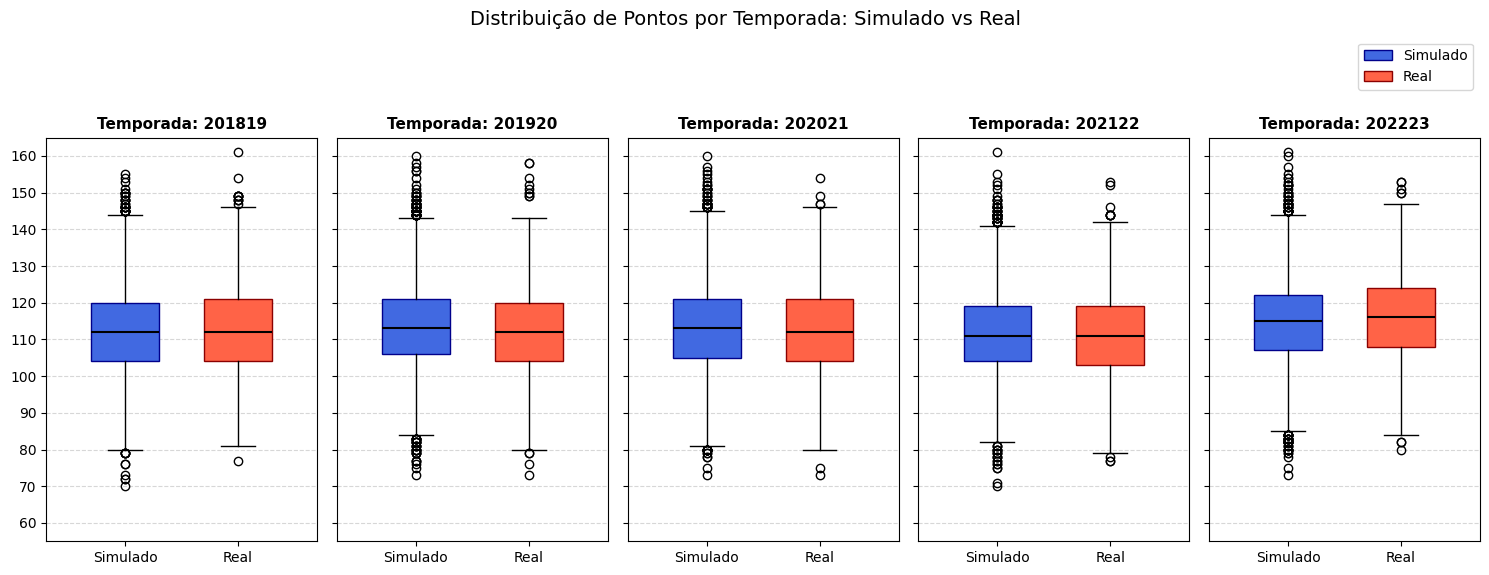

In [102]:

df_completo = pd.concat([
    dict_metricas_simulacao["pontos_dist"][["season", "home_points"]].assign(tipo = "simulado"),

    full_pbp_tokenized\
    .query("season < '202324'")\
    .groupby(["season", "game_id"], as_index = False, dropna = False)[["hpts", "vpts"]].max()\
    [["season", "hpts"]].assign(tipo = "real").rename(columns = {"hpts": "home_points"})
])


fig, axes = plt.subplots(1, 5, figsize=(15, 6), sharey=True)


# --- 3. LOOP PARA GERAR CADA QUADRO ---
for i, season in enumerate(["201819", "201920", "202021", "202122", "202223"]):
    ax = axes[i]

    # 1. Filtra os dados da temporada atual
    df_temporada = df_completo.query("season == @season")
    
    # 2. Separa a coluna numérica 'home_points' para simulações e reais
    dados_simulado = df_temporada.query("tipo == 'simulado'")["home_points"]
    dados_real = df_temporada.query("tipo == 'real'")["home_points"]

    # 3. Passa a lista com as duas séries numéricas para o boxplot
    bp = ax.boxplot(
        [dados_simulado, dados_real],
        positions=[1, 2],
        patch_artist=True,
        widths=0.6,
    )

    # Colorir as caixas especificamente deste quadro
    bp["boxes"][0].set_facecolor("royalblue")  # Caixa 1: Simulado
    bp["boxes"][0].set_edgecolor("darkblue")

    bp["boxes"][1].set_facecolor("tomato")  # Caixa 2: Real
    bp["boxes"][1].set_edgecolor("darkred")

    # Ajustar linhas medianas internas para preto
    for mediana in bp["medians"]:
        mediana.set_color("black")
        mediana.set_linewidth(1.5)

    # Configurações de texto e eixos do quadro atual
    ax.set_title(f"Temporada: {season}", fontsize=11, fontweight="bold")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Simulado", "Real"])  # Legenda curta abaixo de cada caixa
    ax.set_xlim(0.3, 2.7)  # Margem interna para as caixas não colarem nas bordas

    # --- PERSONALIZAÇÃO DO EIXO Y (Aplicado ao grid de cada quadro) ---
    valor_min, valor_max, passo = 60, 160, 10  # Ajuste esses limites aos seus dados
    valores_y = np.arange(valor_min, valor_max + 1, passo)

    ax.set_yticks(valores_y)
    ax.set_ylim(valor_min - 5, valor_max + 5)

    # Grid horizontal tracejado e sutil por trás das caixas
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)


# --- 4. AJUSTES GERAIS DA FIGURA ---
# Título principal do projeto inteiro
fig.suptitle(
    "Distribuição de Pontos por Temporada: Simulado vs Real",
    fontsize=14,
    y=0.95,
)

# Legenda global no topo direito
legend_elements = [
    Patch(facecolor="royalblue", edgecolor="darkblue", label="Simulado"),
    Patch(facecolor="tomato", edgecolor="darkred", label="Real"),
]
axes[4].legend(
    handles=legend_elements, loc="upper right", bbox_to_anchor=(1, 1.25)
)

plt.tight_layout()
plt.show()

season
201819    Axes(0.125,0.11;0.775x0.77)
201920    Axes(0.125,0.11;0.775x0.77)
202021    Axes(0.125,0.11;0.775x0.77)
202122    Axes(0.125,0.11;0.775x0.77)
202223    Axes(0.125,0.11;0.775x0.77)
202324    Axes(0.125,0.11;0.775x0.77)
Name: hpts, dtype: object

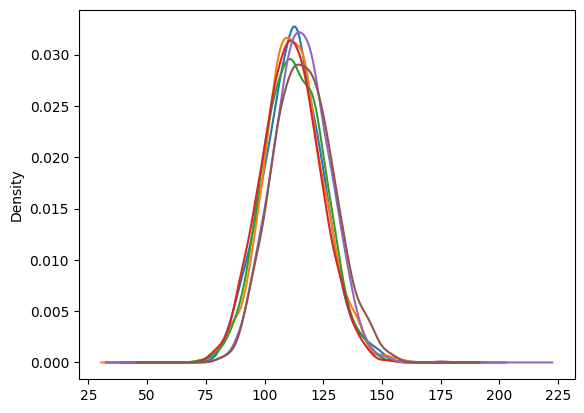

In [72]:
full_pbp_tokenized\
.groupby(["season", "game_id"], as_index = False, dropna = False)[["hpts", "vpts"]].max()\
.groupby("season")["hpts"].plot(kind = "density")

In [106]:
full_pbp_tokenized

,game_id,period,clock,token,last_time,time,spent_time,limhfouls,limvfouls,hpts,vpts,dif,season,tp_token,token_int
0,21800001,1,12:00:00,p000_12(1)p455_10(0),7200,7200,0,4,4,0,0,0,201819,"[12, 10]",87
1,21800001,1,11:40:00,p500_2(5)p200_4(0t),7200,7000,200,4,4,0,0,0,201819,"[2, 4]",152
2,21800001,1,11:15:00,p400_2(5),7000,6750,250,4,4,0,0,0,201819,[2],144
3,21800001,1,11:13:00,p500_4(0p),6750,6730,20,4,4,0,0,0,201819,[4],240
4,21800001,1,11:08:00,p540_5(11p),6730,6680,50,4,4,0,0,0,201819,[5],281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2565572,52200211,4,00:50:80,p540_5(35p),650,508,142,1,0,120,93,27,202223,[5],334
2565573,52200211,4,00:47:50,p401_5(12p),508,475,33,1,0,120,93,27,202223,[5],282
2565574,52200211,4,00:37:70,p550_1(3a),475,377,98,1,0,120,95,25,202223,[1],29
2565575,52200211,4,00:13:60,p201_5(37t),377,136,241,1,0,120,95,25,202223,[5],337


In [ ]:
list_resultados = []
for p in [1, 2, 3, 4]:
    for t in np.arange(7200, -1, -10):
        full_pbp_tokenized.query("period == @ & time >= t").groupby(["season", "game_id"])[[	hpts,"vpts"]]

#

7200
7190
7180
7170
7160
7150
7140
7130
7120
7110
7100
7090
7080
7070
7060
7050
7040
7030
7020
7010
7000
6990
6980
6970
6960
6950
6940
6930
6920
6910
6900
6890
6880
6870
6860
6850
6840
6830
6820
6810
6800
6790
6780
6770
6760
6750
6740
6730
6720
6710
6700
6690
6680
6670
6660
6650
6640
6630
6620
6610
6600
6590
6580
6570
6560
6550
6540
6530
6520
6510
6500
6490
6480
6470
6460
6450
6440
6430
6420
6410
6400
6390
6380
6370
6360
6350
6340
6330
6320
6310
6300
6290
6280
6270
6260
6250
6240
6230
6220
6210
6200
6190
6180
6170
6160
6150
6140
6130
6120
6110
6100
6090
6080
6070
6060
6050
6040
6030
6020
6010
6000
5990
5980
5970
5960
5950
5940
5930
5920
5910
5900
5890
5880
5870
5860
5850
5840
5830
5820
5810
5800
5790
5780
5770
5760
5750
5740
5730
5720
5710
5700
5690
5680
5670
5660
5650
5640
5630
5620
5610
5600
5590
5580
5570
5560
5550
5540
5530
5520
5510
5500
5490
5480
5470
5460
5450
5440
5430
5420
5410
5400
5390
5380
5370
5360
5350
5340
5330
5320
5310
5300
5290
5280
5270
5260
5250
5240
5230
5220
5210


In [9]:
# df_ = pd.read_parquet("C:/Users/User/Documents/recuperacao_arquivoshd/Mestrado/NBA/nba/data/processed/pbp_season_files/api/pbpa_total.parquet")

In [10]:
# df_.query("SEASON >= '2018-19' & EVENTMSGTYPE == '11'")

In [11]:
# df_.query("SEASON >= '2018-19'")\
# .groupby(["EVENTMSGTYPE", "EVENTMSGACTIONTYPE"], as_index = False, dropna = False).size()\
# .groupby(["EVENTMSGTYPE"], as_index = False).size()

In [4]:
pd.set_option("display.max_columns", None)

In [5]:
def get_model_features(file):

    model_features = file.split("\\")[-1].split("/")[-1]\
    .replace(".parquet", "")\
    .replace("simulations_", "")\
    .replace("_seasondata", ";seasondata?")\
    .replace("_context", ";context?")\
    .replace("_embedding", ";embedding?")\
    .replace("_numlayers", ";numlayers?")\
    .replace("_numneurons", ";numneurons?")\
    .replace("_nodropout", ";dropout?0")\
    .replace("_dropout0", ";dropout?0.")\
    .replace("_layernorm", ";layernorm?")\
    .replace("_setcovariables", ";setcovariables?")\
    .split(";")

    return pd.DataFrame(data = model_features, columns = ["key_value"])\
    .reset_index()\
    .assign(key = lambda df: np.where(df["index"] == 0, "model", ""))\
    .assign(value = lambda df: np.where(df["index"] == 0, df["key_value"], ""))\
    .assign(key_value = lambda df: df["key_value"].str.split("?"))\
    .assign(key = lambda df: np.where(df["index"] != 0, df["key_value"].apply(lambda x: x[0]), df["key"]))\
    .assign(value = lambda df: np.where(df["index"] != 0, df["key_value"].apply(lambda x: x[-1]), df["value"]))\
    .assign(aux = 1)\
    .pivot_table(index = "aux", columns = "key", values = "value", aggfunc = lambda x: x)\
    .reset_index(drop = True)\
    [["model", "seasondata", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"]]

def build_mean_points(df_):
    # malha de tempo (descendo 7200 -> 0 de 10 em 10)
    times = np.arange(7200, -1, -10, dtype=np.int16)

    # filtra só tempos regulamentares
    df = df_.loc[df_["period"].le(4), ["sim_id", "period", "remaining_time", "home_points", "away_points"]].copy()

    # arredonda/encaixa no grid de 10s (use int pra acelerar)
    df["remaining_time_secs"] = (df["remaining_time"].astype(np.int32) // 10 * 10).astype(np.int16)

    # ordena pra shift/ffill funcionarem direito (tempo desc)
    df = df.sort_values(["sim_id", "period", "remaining_time_secs"], ascending=[True, True, False])

    # detecta mudanças de placar DENTRO de cada sim_id+period (vetorizado)
    g = df.groupby(["sim_id", "period"], sort=False)
    h_prev = g["home_points"].shift(1)
    a_prev = g["away_points"].shift(1)

    changed = df["home_points"].ne(h_prev) | df["away_points"].ne(a_prev)
    start_q = df["remaining_time_secs"].eq(7200)

    df = df.loc[changed | start_q]

    # consolida: um valor por (sim_id, period, time)
    df = (
        df.groupby(["sim_id", "period", "remaining_time_secs"], as_index=False, sort=False)[["home_points", "away_points"]]
          .max()
    )

    out_parts = []
    # processa por período pra reduzir pico de memória
    for p, dpp in df.groupby("period", sort=False):
        sims = dpp["sim_id"].unique()

        # MultiIndex completo: (sim_id x time)
        full_idx = pd.MultiIndex.from_product(
            [sims, times],
            names=["sim_id", "remaining_time_secs"]
        )

        # reindex + ffill por sim_id
        dpp2 = (
            dpp.set_index(["sim_id", "remaining_time_secs"])[["home_points", "away_points"]]
               .reindex(full_idx)
               .groupby(level=0, sort=False)
               .ffill()
        )

        # agrega média no período
        mean_pp = dpp2.groupby(level=1, sort=False).mean(numeric_only=True)
        mean_pp = mean_pp.reset_index()
        mean_pp.insert(0, "period", p)

        out_parts.append(mean_pp)

    out = (
        pd.concat(out_parts, ignore_index=True)
          .sort_values(["period", "remaining_time_secs"], ascending=[True, False], ignore_index=True)
    )
    return out

def get_points_by_categorical_variables_complete_time(df_):
    list_labels = [
        "a. ( <= -20)", "b. (entre -19 e -11)", "c. (entre -10 e -7)",
        "d. (entre -6 e -4)", "e. (entre -3 e -1)", "f. empatado",
        "g. (entre 1 e 3)", "h. (entre 4 e 6)", "i. (entre 7 e 10)",
        "j. (entre 11 e 19)", "k. ( >= 20)"
    ]
    list_time_marks = [-1, 100, 200, 600, 1200, 1800, 2400, 3000, 3600, 4200, 4800, 5400, 6000, 6600, 7200]

    # rótulos do cat_time: primeiro vira 0 (no seu código você converte -1 -> 0)
    time_labels = list_time_marks[:-1].copy()
    time_labels[0] = 0
    time_labels = np.array(time_labels, dtype = np.int16)

    # 1) base + cat_time
    df = df_.query("period <= 4")[["sim_id", "period", "remaining_time", "home_points", "away_points"]].copy()

    df["cat_time"] = pd.cut(df["remaining_time"], bins = list_time_marks, labels = time_labels).astype("int16")

    # 2) garante unicidade (senão dá o erro de multiindex duplicado)
    df = (
        df.groupby(["sim_id", "period", "cat_time"], as_index = False, sort = False)[["home_points", "away_points"]]
          .max()
    )

    # 3) COMPLETA A GRADE (sim_id x cat_time) dentro de cada period e faz ffill por sim_id
    parts = []
    for p, dpp in df.groupby("period", sort = False):
        sims = dpp["sim_id"].unique()

        full_idx = pd.MultiIndex.from_product(
            [sims, time_labels],
            names=["sim_id", "cat_time"]
        )

        filled = (
            dpp.set_index(["sim_id", "cat_time"])[["home_points", "away_points"]]
               .reindex(full_idx)
               .groupby(level = 0, sort = False)
               .bfill()
               .reset_index()
        )
        filled.insert(1, "period", p)
        parts.append(filled)

    df_full = pd.concat(parts, ignore_index = True)

    # 4) segue sua lógica original (agora com todos cat_time presentes)
    df_full = (
        df_full
        .sort_values(["sim_id", "period", "cat_time"], ascending=[True, True, False])
        .assign(lag_hp = lambda d: d.groupby("sim_id")["home_points"].shift(1).fillna(0))
        .assign(lag_ap = lambda d: d.groupby("sim_id")["away_points"].shift(1).fillna(0))
        .assign(dif = lambda d: d["lag_hp"] - d["lag_ap"])
        .assign(cat_dif = lambda d: pd.cut(d["dif"],
            bins = [-100, -19.5, -10.5, -6.5, -3.5, -0.5, 0.5, 3.5, 6.5, 10.5, 19.5, 100],
            labels = list_labels
        ).astype("str"))
        # lags iguais ao seu código: por sim_id (carrega entre períodos)
        .assign(hp = lambda d: d["home_points"] - d["lag_hp"])
        .assign(ap = lambda d: d["away_points"] - d["lag_ap"])
        .assign(cnt = 1)

        .groupby(["period", "cat_time", "cat_dif"], as_index = False, dropna = False)
        .agg({"cnt": "sum", "hp": "mean", "ap": "mean"})
        .sort_values(["period", "cat_time", "cat_dif"], ascending = [True, False, True])

    )



    return df_full

def get_ks_statistics(var1, var2):

    resultado_ks = ks_2samp(data1 = var1, data2 = var2)
    df_resultado_ks = pd.DataFrame([{"ks_statistic": resultado_ks.statistic,
                                     "ks_pvalue": resultado_ks.pvalue,
                                     "ks_statistic_location": resultado_ks.statistic_location,
                                     "ks_statistic_sign": resultado_ks.statistic_sign}])
    return df_resultado_ks

def get_jensen_shannon_statistic(var1, var2):
    var1 = np.asarray(var1)
    var2 = np.asarray(var2)

    # remover NA, se houver
    var1 = var1[~np.isnan(var1)]
    var2 = var2[~np.isnan(var2)]

    # se uma das amostras estiver vazia, não há como comparar
    if len(var1) == 0 or len(var2) == 0:
        return np.nan

    min_score = min(var1.min(), var2.min())
    max_score = max(var1.max(), var2.max())
    support = np.arange(min_score, max_score + 1)

    real_counts = np.array([(var1 == s).sum() for s in support], dtype=float)
    sim_counts  = np.array([(var2 == s).sum() for s in support], dtype=float)

    real_total = real_counts.sum()
    sim_total = sim_counts.sum()

    # proteção extra
    if real_total == 0 or sim_total == 0:
        return np.nan

    real_probs = real_counts / real_total
    sim_probs  = sim_counts / sim_total

    dist_js = jensenshannon(real_probs, sim_probs)
    return dist_js

def get_comparative_distribution_metrics(var1, var2):

    ks_ = get_ks_statistics(var1, var2)
    wasserstein_ = wasserstein_distance(var1, var2)
    js_ = get_jensen_shannon_statistic(var1, var2)

    final_df = ks_\
    .assign(wasserstein_distance = wasserstein_)\
    .assign(jensen_shannon = js_)

    return final_df

def create_base_df_period_cat_time_cat_dif() -> pd.DataFrame:
    periods = [1, 2, 3, 4]

    cat_dif = [
        "a. ( <= -20)", "b. (entre -19 e -11)", "c. (entre -10 e -7)",
        "d. (entre -6 e -4)", "e. (entre -3 e -1)", "f. empatado",
        "g. (entre 1 e 3)", "h. (entre 4 e 6)", "i. (entre 7 e 10)",
        "j. (entre 11 e 19)", "k. ( >= 20)"
    ]

    cat_time = [0, 100, 200, 600, 1200, 1800, 2400, 3000, 3600, 4200, 4800, 5400, 6000, 6600]

    df_base = pd.DataFrame(
        product(periods, cat_time, cat_dif),
        columns=["period", "cat_time", "cat_dif"]
    )

    return df_base

def get_metrics_cat_diff_time_variables(df):
    mae_prop = np.abs(df["error_prop"]).mean()
    max_error_prop = np.abs(df["error_prop"]).max()
    rmse_prop = np.sqrt((df["error_prop"] ** 2).mean())

    # máscaras
    mask_hp = df["error_hp"].notna() & df["real_prop"].notna()
    mask_ap = df["error_ap"].notna() & df["real_prop"].notna()

    # coverage
    coverage_hp = mask_hp.sum() / df["real_hp"].notna().sum()
    coverage_ap = mask_ap.sum() / df["real_ap"].notna().sum()

    # pesos
    w_hp = df.loc[mask_hp, "real_prop"]
    w_ap = df.loc[mask_ap, "real_prop"]

    # hp
    mae_hp = (w_hp * np.abs(df.loc[mask_hp, "error_hp"])).sum() / w_hp.sum()
    rmse_hp = np.sqrt((w_hp * (df.loc[mask_hp, "error_hp"] ** 2)).sum() / w_hp.sum())

    corr_pearson_hp = df.loc[mask_hp, ["real_hp", "hp"]].corr(method="pearson").iloc[0, 1]
    corr_spearman_hp = df.loc[mask_hp, ["real_hp", "hp"]].corr(method="spearman").iloc[0, 1]

    # ap
    mae_ap = (w_ap * np.abs(df.loc[mask_ap, "error_ap"])).sum() / w_ap.sum()
    rmse_ap = np.sqrt((w_ap * (df.loc[mask_ap, "error_ap"] ** 2)).sum() / w_ap.sum())

    corr_pearson_ap = df.loc[mask_ap, ["real_ap", "ap"]].corr(method="pearson").iloc[0, 1]
    corr_spearman_ap = df.loc[mask_ap, ["real_ap", "ap"]].corr(method="spearman").iloc[0, 1]

    df_final = pd.DataFrame({
        "mae_prop": [mae_prop],
        "max_error_prop": [max_error_prop],
        "rmse_prop": [rmse_prop],
        "coverage_hp": [coverage_hp],
        "mae_hp": [mae_hp],
        "rmse_hp": [rmse_hp],
        "corr_pearson_hp": [corr_pearson_hp],
        "corr_spearman_hp": [corr_spearman_hp],
        "coverage_ap": [coverage_ap],
        "mae_ap": [mae_ap],
        "rmse_ap": [rmse_ap],
        "corr_pearson_ap": [corr_pearson_ap],
        "corr_spearman_ap": [corr_spearman_ap]
    })

    return df_final

def get_prop_tp_tokens(df, dict_tokens):
    df_ = df\
    .assign(token_ = lambda df: df["token"].map(dict_tokens))\
    .assign(tp_token = lambda df: df["token_"].str.replace("\)p", ");p", regex = True).str.replace("p[0-9]{3}_", "", regex = True))\
    .assign(tp_token = lambda df: df["tp_token"].str.replace("\(.+?\)", "", regex = True).str.split(";"))

    return pd.DataFrame(data = df_["tp_token"].to_list(), index = df_.index)\
    .stack().reset_index()\
    .rename(columns = {0: "tp_token"})\
    .astype({"tp_token": "int"})\
    .set_index("level_0")\
    .merge(df_[["sim_id"]], how = "left", left_index = True, right_index  = True)\
    .assign(num_sim = lambda df: df["sim_id"].nunique())\
    .groupby(["num_sim", "tp_token"], as_index = False, dropna = False).size()\
    .assign(prop = lambda df: df["size"] / df["num_sim"])\
    [["tp_token", "prop"]]

def get_match_splits(df, num_secs = 300):
    num_breaks = [i for i in range(0, 7201, num_secs)]
    num_labels = [str(i) + "-" + str(j) for i, j in zip(num_breaks[:-1], num_breaks[1:])]
    num_breaks[0] -= 1
    num_breaks[-1] += 1
    return df.assign(cat_time = lambda df: pd.cut(df["remaining_time"], bins = num_breaks, labels = num_labels))

def get_stats_simulations(file, dict_real_values, dict_tokens):
    
    if isinstance(file, str): 
        df_ = pd.read_parquet(file)
        df_features_model = get_model_features(file)

    if isinstance(file, list): 
        list_df = []
        for ff in file:
            df_ = pd.read_parquet(ff)
            list_df.append(df_)

        df_ = pd.concat(list_df).reset_index(drop = True)
        df_features_model = get_model_features(file[0].split("_parte")[0])

    dict_stats = {}
    dict_comparison = {}

    # final outcome
    df_final_points = df_.query("period <= 4")\
    .groupby("sim_id")[["home_points", "away_points"]].max()\
    .assign(dif = lambda df: df["home_points"] - df["away_points"])

    df_outcome = df_final_points\
    .assign(outcome = lambda df: np.where(df["home_points"] > df["away_points"], "home_win", "draw"))\
    .assign(outcome = lambda df: np.where(df["home_points"] < df["away_points"], "away_win", df["outcome"]))\
    .groupby("outcome", as_index = False).size()\
    .assign(perc = lambda df: df["size"] / df["size"].sum())\
    .assign(aux = 1)\
    .pivot_table(index = "aux", columns = "outcome", values = "perc")\
    .reset_index(drop = True)

    dict_stats["outcome"] = df_features_model.assign(aux = 1)\
    .merge(df_outcome.assign(aux = 1), how = "left")\
    .drop(columns = "aux")


    dict_comparison["outcome"] = dict_stats["outcome"]\
    .merge(dict_real_values["outcome"], how = "left")\
    .assign(dif_prop_away = lambda df: df["away_win"] - df["real_away_win"])\
    .assign(dif_prop_draw = lambda df: df["draw"] - df["real_draw"])\
    .assign(dif_prop_away = lambda df: np.abs(df["dif_prop_away"]) / df["real_away_win"])\
    .assign(dif_prop_draw = lambda df: np.abs(df["dif_prop_draw"]) / df["real_draw"])

    # final points
    df_real_data_points_season = dict_real_values["final_points"].loc[dict_real_values["final_points"]["season"] == df_features_model["seasondata"][0]]

    df_points_stats = df_final_points[["home_points", "away_points"]].describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T\
    .reset_index().rename(columns = {"index": "team"})

    dict_stats["points_stats"] = df_features_model.assign(aux = 1)\
    .merge(df_points_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_hpts = get_comparative_distribution_metrics(df_real_data_points_season["hpts"], df_final_points['home_points'])
    df_comparative_apts = get_comparative_distribution_metrics(df_real_data_points_season["vpts"], df_final_points['away_points'])
    df_comparative_difpts = get_comparative_distribution_metrics(df_real_data_points_season["dif"], df_final_points['dif'])

    dict_comparison["comparative_home_points"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_hpts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_away_points"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_apts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_dif_points"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_difpts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # num_plays
    df_real_data_nplays_season = dict_real_values["nplays_period"].loc[dict_real_values["nplays_period"]["season"] == df_features_model["seasondata"][0]]

    df_num_plays = df_\
    .groupby(["sim_id", "period"], as_index = False).size()

    df_num_plays_stats = df_num_plays\
    .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))\
    .groupby("period")["size"].describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])\
    .reset_index()

    dict_stats["num_plays"] = df_features_model.assign(aux = 1)\
    .merge(df_num_plays_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_nplays_1stp = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period == 1")["size"], df_num_plays.query("period == 1")["size"])
    df_comparative_nplays_2ndp = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period == 2")["size"], df_num_plays.query("period == 2")["size"])
    df_comparative_nplays_3rdp = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period == 3")["size"], df_num_plays.query("period == 3")["size"])
    df_comparative_nplays_4thp = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period == 4")["size"], df_num_plays.query("period == 4")["size"])
    df_comparative_nplays_overtime = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period > 4")["size"], df_num_plays.query("period > 4")["size"])

    dict_comparison["comparative_nplays_1st_period"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_1stp.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_nplays_2nd_period"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_2ndp.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_nplays_3rd_period"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_3rdp.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_nplays_4th_period"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_4thp.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_nplays_overtime"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_overtime.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # num_plays by 20secs strip
    df_real_data_nplays_by_20secs_season = dict_real_values["ntokens_20secs_strip"].loc[dict_real_values["ntokens_20secs_strip"]["season"] == df_features_model["seasondata"][0]]

    df_num_plays_by_20secs = df_\
    .pipe(get_match_splits, num_secs = 200)\
    .query("period <= 5")\
    .assign(num_games = lambda df: df.groupby(["period"])["sim_id"].transform("nunique"))\
    .groupby(["num_games", "period", "cat_time"], as_index = False, dropna = False, observed = True).size()\
    .assign(media_ntokens = lambda df: df["size"] / df["num_games"])\
    [["period", "cat_time", "media_ntokens"]]

    dict_stats["nplays_by_20secs_strip"] = df_features_model.assign(aux = 1)\
    .merge(df_num_plays_by_20secs.assign(aux = 1), how = "left")\
    .drop(columns = "aux")\
    .sort_values(["period", "cat_time"], ascending = [True, False]).reset_index(drop = True)

    dict_comparison["nplays_by_20secs_strip"] = dict_stats["nplays_by_20secs_strip"]\
    .merge(df_real_data_nplays_by_20secs_season, how = "left")\
    .assign(dif_media_ntokens = lambda df: df["media_ntokens"] - df["real_media_ntokens"])\
    .sort_values(["period", "cat_time"], ascending = [True, False]).reset_index(drop = True)

    # mean points by secs
    df_real_mean_points_by_seconds_season = dict_real_values["points_by_secs"].loc[dict_real_values["points_by_secs"]["season"] == df_features_model["seasondata"][0]]
    df_mean_points_by_seconds = build_mean_points(df_)

    dict_stats["points_by_secs"] = df_features_model.assign(aux = 1)\
    .merge(df_mean_points_by_seconds.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_points_by_secs_hpts = get_comparative_distribution_metrics(df_real_mean_points_by_seconds_season["home_points"], df_mean_points_by_seconds["home_points"])
    df_comparative_points_by_secs_apts = get_comparative_distribution_metrics(df_real_mean_points_by_seconds_season["away_points"], df_mean_points_by_seconds["away_points"])

    dict_comparison["comparative_home_points_by_secs"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_points_by_secs_hpts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_away_points_by_secs"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_points_by_secs_apts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")


    # points by dif and time
    df_real_points_categorical_dif_and_time_season = dict_real_values["points_by_categorical_dif_time"].loc[dict_real_values["points_by_categorical_dif_time"]["season"] == df_features_model["seasondata"][0]]

    df_points_categorical_dif_and_time = get_points_by_categorical_variables_complete_time(df_ = df_)\
    .assign(total_cnt = lambda df: df.groupby(["period", "cat_time"])["cnt"].transform("sum"))\
    .assign(sim_prop = lambda df: df["cnt"] / df["total_cnt"])

    dict_stats["points_by_cat_time_dif"] = df_features_model.assign(aux = 1)\
    .merge(df_points_categorical_dif_and_time.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_time_diff = create_base_df_period_cat_time_cat_dif()\
    .merge(df_real_points_categorical_dif_and_time_season, how = 'left')\
    .assign(real_prop = lambda df: df["real_prop"].fillna(0))\
    .merge(df_points_categorical_dif_and_time[["period", "cat_time", "cat_dif", "sim_prop", "hp", "ap"]], how = "left")\
    .assign(sim_prop = lambda df: df["sim_prop"].fillna(0))\
    .assign(error_prop = lambda df: df["real_prop"] - df["sim_prop"])\
    .assign(error_hp = lambda df: df["real_hp"] - df["hp"])\
    .assign(error_ap = lambda df: df["real_ap"] - df["ap"])

    df_first46mins_time_dif_metrics = get_metrics_cat_diff_time_variables(df_comparative_time_diff.query("~(period == 4 & cat_time <= 600)"))

    df_final2mins_time_dif_metrics = get_metrics_cat_diff_time_variables(df_comparative_time_diff.query("period == 4 & cat_time <= 600"))

    dict_comparison["comparative_cat_time_diff_first46mins"] = df_features_model.assign(aux = 1)\
    .merge(df_first46mins_time_dif_metrics.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_cat_time_diff_final2mins"] = df_features_model.assign(aux = 1)\
    .merge(df_final2mins_time_dif_metrics.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # lead changes
    df_real_lead_changes_season = dict_real_values["lead_changes"].loc[dict_real_values["lead_changes"]["season"] == df_features_model["seasondata"][0]]

    df_lead_changes = df_\
    .assign(dif = lambda df: df["home_points"] - df["away_points"])\
    .assign(leading = lambda df: np.sign(df["dif"]))\
    .query("dif != 0")\
    .assign(lead_change = lambda df: df.groupby("sim_id")["leading"].diff().fillna(0))\
    .assign(lead_change = lambda df: np.where(df["lead_change"] == 0, 0, 1))\
    .groupby(["sim_id"], as_index = False, dropna = False)["lead_change"].sum()\
    .rename(columns = {"lead_change": "lead_changes"})

    df_lead_changes_stats = df_lead_changes[["lead_changes"]].describe(percentiles = [.01, .05, .1, .25, .5, .75, .9, .95, .99]).T

    dict_stats["lead_changes"] = df_features_model.assign(aux = 1)\
    .merge(df_lead_changes_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_lead_changes = get_comparative_distribution_metrics(df_real_lead_changes_season["real_lead_changes"], df_lead_changes["lead_changes"])

    dict_comparison["comparative_lead_changes"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_lead_changes.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # dist points by minutes
    df_real_points_by_minutes_season = dict_real_values["points_by_minutes"].loc[dict_real_values["points_by_minutes"]["season"] == df_features_model["seasondata"][0]]

    df_points_by_minutes = df_\
    .pipe(get_match_splits, num_secs = 600)\
    .assign(hpts_dif = lambda df: df.groupby("sim_id")["home_points"].diff().fillna(0))\
    .assign(apts_dif = lambda df: df.groupby("sim_id")["away_points"].diff().fillna(0))\
    .groupby(["sim_id", "period", "cat_time"], as_index = False, dropna = False, observed = True)[["hpts_dif", "apts_dif"]].sum()\
    .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))

    df_points_by_minutes_home_stats = df_points_by_minutes\
    .groupby(["period", "cat_time"], as_index = False, dropna = False, observed = True)["hpts_dif"].describe(percentiles = [.01, .05, .1, .25, .5, .75, .9, .95, .99])

    df_points_by_minutes_away_stats = df_points_by_minutes\
    .groupby(["period", "cat_time"], as_index = False, dropna = False, observed = True)["apts_dif"].describe(percentiles = [.01, .05, .1, .25, .5, .75, .9, .95, .99])

    dict_stats["points_by_minutes_home"] = df_features_model.assign(aux = 1)\
    .merge(df_points_by_minutes_home_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_stats["points_by_minutes_away"] = df_features_model.assign(aux = 1)\
    .merge(df_points_by_minutes_away_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_points_by_minutes_hpts = get_comparative_distribution_metrics(df_real_points_by_minutes_season["hpts_dif"], df_points_by_minutes["hpts_dif"])
    df_comparative_points_by_minutes_apts = get_comparative_distribution_metrics(df_real_points_by_minutes_season["apts_dif"], df_points_by_minutes["apts_dif"])

    dict_comparison["comparative_incremento_hp_by_minute"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_points_by_minutes_hpts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_incremento_ap_by_minute"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_points_by_minutes_apts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # prop_tp_tokens
    df_prop_tp_tokens = get_prop_tp_tokens(df_, dict_tokens)

    dict_stats["prop_tp_tokens"] = df_features_model.assign(aux = 1)\
    .merge(df_prop_tp_tokens.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_real_prop_tokens = dict_real_values["prop_tp_tokens_dist"].loc[dict_real_values["prop_tp_tokens_dist"]["season"] == df_features_model["seasondata"][0]]

    dict_comparison["prop_tp_tokens"] = dict_stats["prop_tp_tokens"]\
    .merge(df_real_prop_tokens, how = "left")\
    .assign(dif_props = lambda df: df["prop"] - df["real_prop"])

    dict_results = {"comparison": dict_comparison, "stats": dict_stats}
    return dict_results

In [6]:
data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
#data_folder = "drive/MyDrive/mestrado_final_files/data/"

In [7]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}


In [8]:
tokens_timeout_home_team = ['p550_1(1a)p200_9(0)', 'p500_1(3)p200_9(0)', 'p550_1(3a)p200_9(0)',
                            'p550_1(3a)p200_9(0)p440_8(0)', 'p550_1(5a)p200_9(0)', 'p200_9(0)',
                            'p200_9(0)p001_18(0)', 'p200_9(0)p440_8(0)', 'p200_9(0)p550_8(0)',
                            'p200_9(0)p440_8(0)p440_8(0)', 'p200_9(0)p440_8(0)p550_8(0)',
                            'p200_9(0)p550_8(0)p550_8(0)', 'p200_9(0)p440_8(0)p440_8(0)p440_8(0)',
                            'p200_9(0)p440_8(0)p440_8(0)p550_8(0)', 'p200_9(0)p440_8(0)p550_8(0)p550_8(0)',
                            'p200_9(0)p440_8(0)p440_8(0)p440_8(0)p550_8(0)',
                            'p200_9(0)p440_8(0)p440_8(0)p550_8(0)p550_8(0)', 'p200_9(1)', 'p200_9(1)p001_18(0)']

tokens_timeout_away_team = ['p440_1(1a)p300_9(0)', 'p440_1(1a)p300_9(0)p550_8(0)', 'p400_1(3)p300_9(0)',
                            'p440_1(3a)p300_9(0)', 'p440_1(3a)p300_9(0)p550_8(0)', 'p440_1(5a)p300_9(0)',
                            'p300_9(0)', 'p300_9(0)p001_18(0)', 'p300_9(0)p440_8(0)', 'p300_9(0)p550_8(0)',
                            'p300_9(0)p440_8(0)p440_8(0)', 'p300_9(0)p440_8(0)p550_8(0)', 'p300_9(0)p550_8(0)p550_8(0)',
                            'p300_9(0)p440_8(0)p440_8(0)p550_8(0)', 'p300_9(0)p440_8(0)p550_8(0)p550_8(0)',
                            'p300_9(0)p550_8(0)p550_8(0)p550_8(0)', 'p300_9(0)p440_8(0)p440_8(0)p550_8(0)p550_8(0)',
                            'p300_9(0)p440_8(0)p550_8(0)p550_8(0)p550_8(0)',
                            'p300_9(0)p440_8(0)p440_8(0)p550_8(0)p550_8(0)p550_8(0)', 'p300_9(1)', 'p300_9(1)p001_18(0)']

In [9]:

pbp_tokenized = pd.read_csv(data_folder + "pbp_tokenized.txt", sep = ";")
df_games_nba = pd.read_csv(data_folder + "games_nba.csv", sep = ';')\
.rename(columns = {"GAME_ID": "game_id", "SEASON": "season"})\
.assign(season = lambda df: df["season"].str.replace("\-", "", regex = True))

full_pbp_tokenized = pbp_tokenized\
.merge(df_games_nba[["game_id", "season"]].drop_duplicates(), how = "left")\
.assign(tp_token = lambda df: df["token"].str.replace("\)p", ");p", regex = True).str.replace("p[0-9]{3}_", "", regex = True))\
.assign(tp_token = lambda df: df["tp_token"].str.replace("\(.+?\)", "", regex = True).str.split(";"))\
.assign(token_int = lambda df: df["token"].map(token_to_integer))

del pbp_tokenized

In [10]:
full_pbp_tokenized.query("token.str.contains('p451_6\(11p\)')")

,game_id,period,clock,token,last_time,time,spent_time,limhfouls,limvfouls,hpts,vpts,dif,season,tp_token,token_int
84,21800001,1,01:38:00,p451_6(11p)p500_3(12w)p300_4(1t)p500_3(22c),1040,980,60,0,0,21,15,6,201819,"[6, 3, 4, 3]",458
456,21800002,1,04:34:00,p451_6(11p)p500_3(12c),2740,2740,0,0,2,20,16,4,201819,"[6, 3]",446
464,21800002,1,03:36:00,p451_6(11p)p500_3(12w)p300_4(1t)p500_3(22c),2260,2160,100,0,2,24,19,5,201819,"[6, 3, 4, 3]",458
584,21800002,2,02:21:00,p451_6(11p)p500_3(12c),1460,1410,50,0,0,53,42,11,201819,"[6, 3]",446
782,21800002,4,02:23:00,p451_6(11p)p500_3(12c)p500_3(22c),1510,1430,80,0,1,99,96,3,201819,"[6, 3, 3]",448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2564948,52200201,1,00:32:60,p451_6(11p)p500_3(12c),368,326,42,0,1,29,18,11,202223,"[6, 3]",446
2564952,52200201,1,00:08:60,p451_6(11p)p500_3(12c)p440_8(0)p500_3(22c),224,86,138,0,1,29,21,8,202223,"[6, 3, 8, 3]",452
2565122,52200201,3,00:58:30,p451_6(11p),583,583,0,0,0,67,65,2,202223,[6],442
2565130,52200201,3,00:13:90,p451_6(11p),139,139,0,0,0,67,67,0,202223,[6],442


In [11]:
dict_real_values = {}

dict_real_values["final_points"] = full_pbp_tokenized.query("period <= 4")\
.groupby(["season", "game_id"], as_index = False, dropna = False)[["hpts", "vpts"]].max()\
.assign(dif = lambda df: df["hpts"] - df["vpts"])

dict_real_values["nplays_period"] = full_pbp_tokenized\
.groupby(["season", "game_id", "period"], as_index = False, dropna = False).size()

dict_real_values["points_by_secs"] = full_pbp_tokenized\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "game_id": "sim_id", "time": "remaining_time"})\
.groupby("season")\
.apply(func = build_mean_points, include_groups = False)\
.reset_index("season")

dict_real_values["points_by_categorical_dif_time"] = full_pbp_tokenized\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "game_id": "sim_id", "time": "remaining_time"})\
.groupby("season")\
.apply(func = get_points_by_categorical_variables_complete_time, include_groups = False)\
.reset_index("season")\
.assign(total_cnt = lambda df: df.groupby(["season", "period", "cat_time"])["cnt"].transform("sum"))\
.assign(real_prop = lambda df: df["cnt"] / df["total_cnt"])\
.rename(columns = {"hp": "real_hp", "ap": "real_ap"})

dict_real_values["prop_tp_tokens_dist"] = pd.DataFrame(data = full_pbp_tokenized["tp_token"].to_list(),
                                                       index = full_pbp_tokenized.index)\
.stack().reset_index()\
.rename(columns = {0: "tp_token"})\
.astype({"tp_token": "int"})\
.set_index("level_0")\
.merge(full_pbp_tokenized[["game_id", "season"]], how = "left", left_index = True, right_index  = True)\
.assign(num_games = lambda df: df.groupby("season")["game_id"].transform("nunique"))\
.groupby(["season", "num_games", "tp_token"], as_index = False, dropna = False).size()\
.assign(real_prop = lambda df: df["size"] / df["num_games"])

dict_real_values["lead_changes"] = full_pbp_tokenized\
.assign(leading = lambda df: np.sign(df["dif"]))\
.query("dif != 0")\
.assign(lead_change = lambda df: df.groupby("game_id")["leading"].diff().fillna(0))\
.assign(lead_change = lambda df: np.where(df["lead_change"] == 0, 0, 1))\
.groupby(["season", "game_id"], as_index = False, dropna = False)["lead_change"].sum()\
.rename(columns = {"lead_change": "real_lead_changes"})

dict_real_values["ntokens_20secs_strip"] = full_pbp_tokenized\
.rename(columns = {"time": "remaining_time"})\
.query("period <= 5")\
.pipe(get_match_splits, num_secs = 200)\
.assign(num_games = lambda df: df.groupby(["season", "period"])["game_id"].transform("nunique"))\
.groupby(["season", "num_games", "period", "cat_time"], as_index = False, dropna = False, observed = True).size()\
.assign(real_media_ntokens = lambda df: df["size"] / df["num_games"])\
[["season", "period", "cat_time", "real_media_ntokens"]]

dict_real_values["points_by_minutes"] = full_pbp_tokenized\
.rename(columns = {"time": "remaining_time"})\
.pipe(get_match_splits, num_secs = 600)\
.assign(hpts_dif = lambda df: df.groupby("game_id")["hpts"].diff().fillna(0))\
.assign(apts_dif = lambda df: df.groupby("game_id")["vpts"].diff().fillna(0))\
.groupby(["season", "game_id", "period", "cat_time"], as_index = False, dropna = False, observed = True)[["hpts_dif", "apts_dif"]].sum()\
.assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))

dict_real_values["outcome"]  = dict_real_values["final_points"]\
.assign(outcome = lambda df: np.where(df["hpts"] > df["vpts"], "real_home_win", "real_draw"))\
.assign(outcome = lambda df: np.where(df["hpts"] < df["vpts"], "real_away_win", df["outcome"]))\
.groupby(["season", "outcome"], as_index = False).size()\
.assign(size_season = lambda df: df.groupby("season")["size"].transform("sum"))\
.assign(perc = lambda df: df["size"] / df["size_season"])\
.pivot_table(index = "season", columns = "outcome", values = "perc")\
.reset_index()\
.rename(columns = {"season": "seasondata"})

In [19]:
dict_real_values["outcome"]

outcome,seasondata,real_away_win,real_draw,real_home_win
0,201819,0.384909,0.054116,0.560976
1,201920,0.423447,0.065617,0.510936
2,202021,0.426496,0.051282,0.522222
3,202122,0.428571,0.044596,0.526833
4,202223,0.390909,0.063636,0.545455
5,202324,0.425301,0.048193,0.526506


In [14]:
simulations_folder = "../simulations/"
summary_simulations_folder = "../summary_simulations/"


In [15]:

list_results = []

In [22]:
os.listdir()

['01_functions_training.ipynb',
 '02_functions_simulations.ipynb',
 '03_functions_variation_problem.ipynb',
 '00_functions_preprocess.ipynb',
 '04_functions_competitive_balance.ipynb',
 '00_preprocess_data_models.ipynb',
 '05_functions_descriptive_analysis.ipynb',
 '00_descriptive_analysis_exploratory.ipynb',
 '00_train_models_ngram_split.ipynb',
 '01_train_models_ngram_variation_problem.ipynb',
 '02_train_models_ngram_constant_value.ipynb',
 '03_Simulatorngram.ipynb',
 '06_functions_simulations.ipynb',
 '04_Simulatorngram.ipynb',
 '05_simulator_variation_problem.ipynb',
 '01_train_token_models_structure_NGramModel_ExtraInfo.ipynb',
 '00_train_token_models_structure_NGramModel.ipynb',
 '02_train_token_models_structure_NGramModel_State.ipynb',
 '01_preprocess_covariables_set.ipynb',
 '03_train_token_models_structure_NGramModel_ExtraInfo_State.ipynb',
 '01_simulatorngram_structure_NGramModel_ExtraInfo.ipynb',
 '01_train_time_models_structure_SpentTimeModel.ipynb',
 '.ipynb_checkpoints',


['NGramModel_ExtraInfo',
 'NGramModel_ExtraInfo_two_models',
 'NGramModel_ExtraInfo_State',
 'NGramModel_ExtraInfo_TimeDiffTower',
 'NGramModel_ExtraInfo_MultiTowers']

In [26]:
for folder in [folder for folder in os.listdir(simulations_folder) if "FinalSimulations" not in folder and ".pkl" not in folder and ".parquet" not in folder and ".ini" not in folder]:
    if folder == "desktop.ini":
        continue
    print(folder)
    
    # Caminho completo da pasta atual do loop
    current_folder_path = os.path.join(simulations_folder, folder)

    
    for filename_pattern in tqdm.tqdm([item for item in os.listdir(current_folder_path) if "_parte1." in item]):
        
        # Lista apenas os nomes dos arquivos
        list_files_names = [item for item in os.listdir(current_folder_path) 
                            if filename_pattern.split("_parte")[0] in item and "parte" in item]
        
        # Cria caminhos absolutos com o prefixo do Windows para caminhos longos (\\?\)
        list_files = []
        for item in list_files_names:
            caminho_relativo = os.path.join(current_folder_path, item)
            caminho_absoluto = Path(caminho_relativo).resolve()
            list_files.append(f"\\\\?\\{caminho_absoluto}")

        # Define o nome do arquivo de saída
        output_file = filename_pattern.split("_parte")[0].replace("simulations", "stats_simulations") + ".parquet"
        
        if output_file in os.listdir(summary_simulations_folder):
            continue

        # Executa a função passando a lista de caminhos longos corrigidos (sem mudar de pasta!)
        dict_results = get_stats_simulations(list_files, dict_real_values, integer_to_token)

        # Salva o arquivo usando o caminho correto
        output_path = os.path.join(summary_simulations_folder, output_file)
        with open(output_path, 'wb') as f:
            pickle.dump(dict_results, f)

NGramModel_ExtraInfo


100%|██████████| 80/80 [00:02<00:00, 35.78it/s]


NGramModel_ExtraInfo_two_models


100%|██████████| 80/80 [00:02<00:00, 36.23it/s]


NGramModel_ExtraInfo_State


100%|██████████| 80/80 [00:02<00:00, 35.68it/s]


NGramModel_ExtraInfo_TimeDiffTower


100%|██████████| 40/40 [00:00<00:00, 47.99it/s]


NGramModel_ExtraInfo_MultiTowers


100%|██████████| 40/40 [00:00<00:00, 48.67it/s]


In [42]:
dict_real_values["final_points"]#["hpts"].plot(kind = "density")

,season,game_id,hpts,vpts,dif
0,201819,21800001,105,87,18
1,201819,21800002,108,100,8
2,201819,21800003,112,113,-1
3,201819,21800004,103,100,3
4,201819,21800005,111,83,28
...,...,...,...,...,...
7093,202324,22301226,112,125,-13
7094,202324,22301227,133,123,10
7095,202324,22301228,106,114,-8
7096,202324,22301229,119,128,-9


In [43]:
file = [simulations_folder + "FinalSimulations/" + folder for folder in os.listdir(simulations_folder + "FinalSimulations") if ".ini" not in folder]

In [44]:
list_df = []
for ff in file:
    df_ = pd.read_parquet(ff).assign(file_ = ff)
    list_df.append(df_)

df_ = pd.concat(list_df).reset_index(drop = True)
df_features_model = get_model_features(file[0].split("_parte")[0])


MemoryError: Unable to allocate 6.72 GiB for an array with shape (5, 180264205) and data type int64

In [ ]:
def get_stats_simulations(file, dict_real_values, dict_tokens):
    
    if isinstance(file, str): 
        df_ = pd.read_parquet(file)
        df_features_model = get_model_features(file)

    if isinstance(file, list): 
        list_df = []
        for ff in file:
            df_ = pd.read_parquet(ff)
            list_df.append(df_)

        df_ = pd.concat(list_df).reset_index(drop = True)
        df_features_model = get_model_features(file[0].split("_parte")[0])

    dict_stats = {}
    dict_comparison = {}

    # final outcome
    df_final_points = df_.query("period <= 4")\
    .groupby("sim_id")[["home_points", "away_points"]].max()\
    .assign(dif = lambda df: df["home_points"] - df["away_points"])

    df_outcome = df_final_points\
    .assign(outcome = lambda df: np.where(df["home_points"] > df["away_points"], "home_win", "draw"))\
    .assign(outcome = lambda df: np.where(df["home_points"] < df["away_points"], "away_win", df["outcome"]))\
    .groupby("outcome", as_index = False).size()\
    .assign(perc = lambda df: df["size"] / df["size"].sum())\
    .assign(aux = 1)\
    .pivot_table(index = "aux", columns = "outcome", values = "perc")\
    .reset_index(drop = True)

    dict_stats["outcome"] = df_features_model.assign(aux = 1)\
    .merge(df_outcome.assign(aux = 1), how = "left")\
    .drop(columns = "aux")


    dict_comparison["outcome"] = dict_stats["outcome"]\
    .merge(dict_real_values["outcome"], how = "left")\
    .assign(dif_prop_away = lambda df: df["away_win"] - df["real_away_win"])\
    .assign(dif_prop_draw = lambda df: df["draw"] - df["real_draw"])\
    .assign(dif_prop_away = lambda df: np.abs(df["dif_prop_away"]) / df["real_away_win"])\
    .assign(dif_prop_draw = lambda df: np.abs(df["dif_prop_draw"]) / df["real_draw"])

    # final points
    df_real_data_points_season = dict_real_values["final_points"].loc[dict_real_values["final_points"]["season"] == df_features_model["seasondata"][0]]

    df_points_stats = df_final_points[["home_points", "away_points"]].describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T\
    .reset_index().rename(columns = {"index": "team"})

    dict_stats["points_stats"] = df_features_model.assign(aux = 1)\
    .merge(df_points_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_hpts = get_comparative_distribution_metrics(df_real_data_points_season["hpts"], df_final_points['home_points'])
    df_comparative_apts = get_comparative_distribution_metrics(df_real_data_points_season["vpts"], df_final_points['away_points'])
    df_comparative_difpts = get_comparative_distribution_metrics(df_real_data_points_season["dif"], df_final_points['dif'])

    dict_comparison["comparative_home_points"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_hpts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_away_points"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_apts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_dif_points"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_difpts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # num_plays
    df_real_data_nplays_season = dict_real_values["nplays_period"].loc[dict_real_values["nplays_period"]["season"] == df_features_model["seasondata"][0]]

    df_num_plays = df_\
    .groupby(["sim_id", "period"], as_index = False).size()

    df_num_plays_stats = df_num_plays\
    .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))\
    .groupby("period")["size"].describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])\
    .reset_index()

    dict_stats["num_plays"] = df_features_model.assign(aux = 1)\
    .merge(df_num_plays_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_nplays_1stp = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period == 1")["size"], df_num_plays.query("period == 1")["size"])
    df_comparative_nplays_2ndp = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period == 2")["size"], df_num_plays.query("period == 2")["size"])
    df_comparative_nplays_3rdp = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period == 3")["size"], df_num_plays.query("period == 3")["size"])
    df_comparative_nplays_4thp = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period == 4")["size"], df_num_plays.query("period == 4")["size"])
    df_comparative_nplays_overtime = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period > 4")["size"], df_num_plays.query("period > 4")["size"])

    dict_comparison["comparative_nplays_1st_period"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_1stp.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_nplays_2nd_period"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_2ndp.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_nplays_3rd_period"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_3rdp.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_nplays_4th_period"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_4thp.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_nplays_overtime"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_overtime.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # num_plays by 20secs strip
    df_real_data_nplays_by_20secs_season = dict_real_values["ntokens_20secs_strip"].loc[dict_real_values["ntokens_20secs_strip"]["season"] == df_features_model["seasondata"][0]]

    df_num_plays_by_20secs = df_\
    .pipe(get_match_splits, num_secs = 200)\
    .query("period <= 5")\
    .assign(num_games = lambda df: df.groupby(["period"])["sim_id"].transform("nunique"))\
    .groupby(["num_games", "period", "cat_time"], as_index = False, dropna = False, observed = True).size()\
    .assign(media_ntokens = lambda df: df["size"] / df["num_games"])\
    [["period", "cat_time", "media_ntokens"]]

    dict_stats["nplays_by_20secs_strip"] = df_features_model.assign(aux = 1)\
    .merge(df_num_plays_by_20secs.assign(aux = 1), how = "left")\
    .drop(columns = "aux")\
    .sort_values(["period", "cat_time"], ascending = [True, False]).reset_index(drop = True)

    dict_comparison["nplays_by_20secs_strip"] = dict_stats["nplays_by_20secs_strip"]\
    .merge(df_real_data_nplays_by_20secs_season, how = "left")\
    .assign(dif_media_ntokens = lambda df: df["media_ntokens"] - df["real_media_ntokens"])\
    .sort_values(["period", "cat_time"], ascending = [True, False]).reset_index(drop = True)

    # mean points by secs
    df_real_mean_points_by_seconds_season = dict_real_values["points_by_secs"].loc[dict_real_values["points_by_secs"]["season"] == df_features_model["seasondata"][0]]
    df_mean_points_by_seconds = build_mean_points(df_)

    dict_stats["points_by_secs"] = df_features_model.assign(aux = 1)\
    .merge(df_mean_points_by_seconds.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_points_by_secs_hpts = get_comparative_distribution_metrics(df_real_mean_points_by_seconds_season["home_points"], df_mean_points_by_seconds["home_points"])
    df_comparative_points_by_secs_apts = get_comparative_distribution_metrics(df_real_mean_points_by_seconds_season["away_points"], df_mean_points_by_seconds["away_points"])

    dict_comparison["comparative_home_points_by_secs"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_points_by_secs_hpts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_away_points_by_secs"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_points_by_secs_apts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")


    # points by dif and time
    df_real_points_categorical_dif_and_time_season = dict_real_values["points_by_categorical_dif_time"].loc[dict_real_values["points_by_categorical_dif_time"]["season"] == df_features_model["seasondata"][0]]

    df_points_categorical_dif_and_time = get_points_by_categorical_variables_complete_time(df_ = df_)\
    .assign(total_cnt = lambda df: df.groupby(["period", "cat_time"])["cnt"].transform("sum"))\
    .assign(sim_prop = lambda df: df["cnt"] / df["total_cnt"])

    dict_stats["points_by_cat_time_dif"] = df_features_model.assign(aux = 1)\
    .merge(df_points_categorical_dif_and_time.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_time_diff = create_base_df_period_cat_time_cat_dif()\
    .merge(df_real_points_categorical_dif_and_time_season, how = 'left')\
    .assign(real_prop = lambda df: df["real_prop"].fillna(0))\
    .merge(df_points_categorical_dif_and_time[["period", "cat_time", "cat_dif", "sim_prop", "hp", "ap"]], how = "left")\
    .assign(sim_prop = lambda df: df["sim_prop"].fillna(0))\
    .assign(error_prop = lambda df: df["real_prop"] - df["sim_prop"])\
    .assign(error_hp = lambda df: df["real_hp"] - df["hp"])\
    .assign(error_ap = lambda df: df["real_ap"] - df["ap"])

    df_first46mins_time_dif_metrics = get_metrics_cat_diff_time_variables(df_comparative_time_diff.query("~(period == 4 & cat_time <= 600)"))

    df_final2mins_time_dif_metrics = get_metrics_cat_diff_time_variables(df_comparative_time_diff.query("period == 4 & cat_time <= 600"))

    dict_comparison["comparative_cat_time_diff_first46mins"] = df_features_model.assign(aux = 1)\
    .merge(df_first46mins_time_dif_metrics.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_cat_time_diff_final2mins"] = df_features_model.assign(aux = 1)\
    .merge(df_final2mins_time_dif_metrics.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # lead changes
    df_real_lead_changes_season = dict_real_values["lead_changes"].loc[dict_real_values["lead_changes"]["season"] == df_features_model["seasondata"][0]]

    df_lead_changes = df_\
    .assign(dif = lambda df: df["home_points"] - df["away_points"])\
    .assign(leading = lambda df: np.sign(df["dif"]))\
    .query("dif != 0")\
    .assign(lead_change = lambda df: df.groupby("sim_id")["leading"].diff().fillna(0))\
    .assign(lead_change = lambda df: np.where(df["lead_change"] == 0, 0, 1))\
    .groupby(["sim_id"], as_index = False, dropna = False)["lead_change"].sum()\
    .rename(columns = {"lead_change": "lead_changes"})

    df_lead_changes_stats = df_lead_changes[["lead_changes"]].describe(percentiles = [.01, .05, .1, .25, .5, .75, .9, .95, .99]).T

    dict_stats["lead_changes"] = df_features_model.assign(aux = 1)\
    .merge(df_lead_changes_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_lead_changes = get_comparative_distribution_metrics(df_real_lead_changes_season["real_lead_changes"], df_lead_changes["lead_changes"])

    dict_comparison["comparative_lead_changes"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_lead_changes.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # dist points by minutes
    df_real_points_by_minutes_season = dict_real_values["points_by_minutes"].loc[dict_real_values["points_by_minutes"]["season"] == df_features_model["seasondata"][0]]

    df_points_by_minutes = df_\
    .pipe(get_match_splits, num_secs = 600)\
    .assign(hpts_dif = lambda df: df.groupby("sim_id")["home_points"].diff().fillna(0))\
    .assign(apts_dif = lambda df: df.groupby("sim_id")["away_points"].diff().fillna(0))\
    .groupby(["sim_id", "period", "cat_time"], as_index = False, dropna = False, observed = True)[["hpts_dif", "apts_dif"]].sum()\
    .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))

    df_points_by_minutes_home_stats = df_points_by_minutes\
    .groupby(["period", "cat_time"], as_index = False, dropna = False, observed = True)["hpts_dif"].describe(percentiles = [.01, .05, .1, .25, .5, .75, .9, .95, .99])

    df_points_by_minutes_away_stats = df_points_by_minutes\
    .groupby(["period", "cat_time"], as_index = False, dropna = False, observed = True)["apts_dif"].describe(percentiles = [.01, .05, .1, .25, .5, .75, .9, .95, .99])

    dict_stats["points_by_minutes_home"] = df_features_model.assign(aux = 1)\
    .merge(df_points_by_minutes_home_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_stats["points_by_minutes_away"] = df_features_model.assign(aux = 1)\
    .merge(df_points_by_minutes_away_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_points_by_minutes_hpts = get_comparative_distribution_metrics(df_real_points_by_minutes_season["hpts_dif"], df_points_by_minutes["hpts_dif"])
    df_comparative_points_by_minutes_apts = get_comparative_distribution_metrics(df_real_points_by_minutes_season["apts_dif"], df_points_by_minutes["apts_dif"])

    dict_comparison["comparative_incremento_hp_by_minute"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_points_by_minutes_hpts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_incremento_ap_by_minute"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_points_by_minutes_apts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # prop_tp_tokens
    df_prop_tp_tokens = get_prop_tp_tokens(df_, dict_tokens)

    dict_stats["prop_tp_tokens"] = df_features_model.assign(aux = 1)\
    .merge(df_prop_tp_tokens.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_real_prop_tokens = dict_real_values["prop_tp_tokens_dist"].loc[dict_real_values["prop_tp_tokens_dist"]["season"] == df_features_model["seasondata"][0]]

    dict_comparison["prop_tp_tokens"] = dict_stats["prop_tp_tokens"]\
    .merge(df_real_prop_tokens, how = "left")\
    .assign(dif_props = lambda df: df["prop"] - df["real_prop"])

    dict_results = {"comparison": dict_comparison, "stats": dict_stats}
    return dict_results

In [24]:
# # original
# for folder in os.listdir(simulations_folder):
#     if folder == "desktop.ini":
#         continue
#     print(folder)
#     for filename in tqdm.tqdm([item for item in os.listdir(simulations_folder + folder) if "_parte" in item]):
#         if filename == "desktop.ini":
#             continue

#         file = simulations_folder + folder + "/" + filename
#         output_file = file.split("/")[-1].replace("simulations", "stats_simulations")

#         if output_file in os.listdir(summary_simulations_folder):
#             continue

#         dict_results = get_stats_simulations(file, dict_real_values, integer_to_token)

#         with open(summary_simulations_folder + output_file, 'wb') as f:
#             pickle.dump(dict_results, f)

#         #list_results.append(dict_results)

#         # list_outcome.append(dict_results["outcome"])
#         # list_points_stats.append(dict_results["points_stats"])
#         # list_num_plays.append(dict_results["num_plays"])
#         # list_comparative_home_points.append(dict_results["comparative_home_points"])
#         # list_comparative_away_points.append(dict_results["comparative_away_points"])
#         # list_comparative_dif_points.append(dict_results["comparative_dif_points"])
#         # list_comparative_nplays_1st_p.append(dict_results["comparative_nplays_1st_period"])
#         # list_comparative_nplays_2nd_p.append(dict_results["comparative_nplays_2nd_period"])
#         # list_comparative_nplays_3rd_p.append(dict_results["comparative_nplays_3rd_period"])
#         # list_comparative_nplays_4th_p.append(dict_results["comparative_nplays_4th_period"])
#         # list_comparative_nplays_ot_p.append(dict_results["comparative_nplays_overtime"])
#         # list_comparative_home_points_by_secs.append(dict_results["comparative_home_points_by_secs"])
#         # list_comparative_away_points_by_secs.append(dict_results["comparative_away_points_by_secs"])
#         # list_comparative_cat_time_diff_first_46mins.append(dict_results["comparative_cat_time_diff_first46mins"])
#         # list_comparative_cat_time_diff_final_2mins.append(dict_results["comparative_cat_time_diff_final2mins"])
#         # list_tp_tokens_prop.append(dict_results["prop_tp_tokens"])



In [24]:
get_model_features(list_files[0])["model"].to_list()

['NGramModel_ExtraInfo_MultiTowers']

In [22]:
summary_simulations_folder

'../summary_simulations/'

# Resumo das 39 métricas de avaliação das arquiteturas de simulação

## Bloco 1 — Desfecho agregado e distribuição final do placar

**O que este bloco mede**  
Este bloco mede se as simulações conseguem reproduzir os resultados agregados mais fundamentais das partidas e a distribuição final da pontuação ao fim do tempo regulamentar.

Ele responde perguntas como:
- as simulações produzem a mesma tendência de vitórias de mandante/visitante?
- produzem a mesma frequência de overtime?
- produzem distribuições finais plausíveis de pontuação e diferença de pontos?

### Métricas

**Métrica 1.** Diferença absoluta relativa da proporção de vitórias da equipe visitante.  
Compara a proporção de vitórias do visitante nas simulações com a proporção observada nas partidas reais.  
Fórmula conceitual: `abs(observado - real) / real`.  
**Quanto menor, melhor.**

**Métrica 2.** Diferença absoluta relativa da proporção de partidas que vão ao overtime.  
Compara a frequência de partidas que terminam empatadas no tempo regulamentar e seguem para overtime nas simulações e nos dados reais.  
Fórmula conceitual: `abs(observado - real) / real`.  
**Quanto menor, melhor.**

**Métrica 3.** Wasserstein distance da variável `pontos da equipe mandante ao final do 4º período`.  
Compara a distribuição da pontuação final do mandante no tempo regulamentar entre simulações e partidas reais.  
**Quanto menor, melhor.**

**Métrica 4.** Wasserstein distance da variável `pontos da equipe visitante ao final do 4º período`.  
Compara a distribuição da pontuação final do visitante no tempo regulamentar entre simulações e partidas reais.  
**Quanto menor, melhor.**

**Métrica 5.** Wasserstein distance da variável `diferença de pontos ao final do 4º período`.  
Compara a distribuição da margem final de vitória/derrota no tempo regulamentar entre simulações e partidas reais.  
**Quanto menor, melhor.**

**Métrica 6.** Wasserstein distance da variável `quantidades de viradas no placar`.  
Compara a distribuição do número de mudanças de liderança por partida entre simulações e partidas reais.
Quanto menor, melhor.

---

## Bloco 2 — Dinâmica temporal da quantidade média de tokens por faixa de 20 segundos

**O que este bloco mede**  
Este bloco mede se as simulações conseguem reproduzir a dinâmica temporal dos eventos do jogo por meio da variável **diferença absoluta média entre a quantidade média de tokens das simulações e a quantidade média de tokens das partidas reais em cada faixa de 20 segundos**.

A ideia central é que a dificuldade não é homogênea ao longo da partida:
- é mais fácil ir bem no regime ordinário do jogo;
- é mais difícil ir bem no fim dos períodos;
- é ainda mais difícil reproduzir o comportamento extremo dos segundos finais;
- e o overtime tem dinâmica própria.

### Métricas

**Métrica 7.** Média da diferença absoluta média entre a quantidade média de tokens simulada e real nas faixas de 20 segundos que representam os primeiros 11 minutos dos períodos 1, 2, 3 e 4.  
Resume o erro médio da simulação no regime ordinário dos períodos regulares.  
**Quanto menor, melhor.**

**Métrica 8.** Média da diferença absoluta média entre a quantidade média de tokens simulada e real nas faixas de 20 segundos que representam o último minuto até os últimos 20 segundos dos períodos 1, 2, 3 e 4.  
Mede o erro médio da simulação na aproximação ao fechamento dos períodos regulares.  
**Quanto menor, melhor.**

**Métrica 9.** Média da diferença absoluta média entre a quantidade média de tokens simulada e real nas faixas de 20 segundos que representam os últimos 20 segundos dos períodos 1, 2 e 3.  
Mede o erro médio da simulação no fechamento extremo dos três primeiros períodos.  
**Quanto menor, melhor.**

**Métrica 10.** Média da diferença absoluta média entre a quantidade média de tokens simulada e real na faixa de 20 segundos que representa os últimos 20 segundos do 4º período.  
Mede o erro médio da simulação no fechamento extremo do tempo regulamentar, que é o ponto mais crítico antes de overtime ou encerramento da partida.  
**Quanto menor, melhor.**

**Métrica 11.** Média da diferença absoluta média entre a quantidade média de tokens simulada e real no overtime do início até o minuto final.  
Mede o erro médio da simulação no regime ordinário do overtime, excluindo o trecho final mais crítico.  
**Quanto menor, melhor.**

**Métrica 12.** Média da diferença absoluta média entre a quantidade média de tokens simulada e real no overtime do minuto final até os últimos 20 segundos.  
Mede o erro médio da simulação na aproximação ao fechamento do overtime.  
**Quanto menor, melhor.**

**Métrica 13.** Média da diferença absoluta média entre a quantidade média de tokens simulada e real nos últimos 20 segundos do overtime.  
Mede o erro médio da simulação no fechamento extremo do overtime, isto é, na região mais crítica do período extra.  
**Quanto menor, melhor.**

---

## Bloco 3 — Trajetória das partidas no espaço `tempo × diferença de pontos`

**O que este bloco mede**  
Este bloco mede se as simulações percorrem os mesmos estados de jogo que as partidas reais.

Cada estado do jogo é definido pela combinação entre:
- uma faixa de tempo;
- uma faixa de diferença de pontos.

Para essas células, são comparadas:
1. a proporção de partidas que passam por cada célula;
2. a proporção dos pontos do mandante em cada célula;
3. a proporção dos pontos do visitante em cada célula.

Esse bloco é importante porque avalia se as simulações não apenas chegam a um placar final plausível, mas também se seguem trajetórias plausíveis ao longo do jogo.

A análise foi separada em dois regimes:
- primeiros 46 minutos da partida;
- últimos 2 minutos do 4º período.

### Métricas para os primeiros 46 minutos

**Métrica 14.** MAE da proporção de partidas por célula de `tempo × diferença de pontos`, considerando os primeiros 46 minutos.  
Mede o erro absoluto médio entre simulações e dados reais na ocupação do espaço de estados ao longo da maior parte da partida.  
**Quanto menor, melhor.**

**Métrica 15.** MAE da proporção de pontos do mandante por célula de `tempo × diferença de pontos`, considerando os primeiros 46 minutos.  
Mede o erro absoluto médio na forma como o mandante pontua ao longo do espaço de estados do jogo.  
**Quanto menor, melhor.**

**Métrica 16.** Correlação de Spearman da proporção de pontos do mandante por célula de `tempo × diferença de pontos`, considerando os primeiros 46 minutos.  
Mede se a estrutura ordinal de pontuação do mandante ao longo das células é semelhante entre simulações e dados reais.  
**Quanto maior, melhor.**

**Métrica 17.** MAE da proporção de pontos do visitante por célula de `tempo × diferença de pontos`, considerando os primeiros 46 minutos.  
Mede o erro absoluto médio na forma como o visitante pontua ao longo do espaço de estados do jogo.  
**Quanto menor, melhor.**

**Métrica 18.** Correlação de Spearman da proporção de pontos do visitante por célula de `tempo × diferença de pontos`, considerando os primeiros 46 minutos.  
Mede se a estrutura ordinal de pontuação do visitante ao longo das células é semelhante entre simulações e dados reais.  
**Quanto maior, melhor.**

### Métricas para os últimos 2 minutos do 4º período

**Métrica 19.** MAE da proporção de partidas por célula de `tempo × diferença de pontos`, considerando os 2 minutos finais.  
Mede o erro absoluto médio entre simulações e dados reais na ocupação do espaço de estados na região mais crítica do tempo regulamentar.  
**Quanto menor, melhor.**

**Métrica 20.** MAE da proporção de pontos do mandante por célula de `tempo × diferença de pontos`, considerando os 2 minutos finais.  
Mede o erro absoluto médio na forma como o mandante pontua no espaço de estados do jogo durante o clutch do tempo regulamentar.  
**Quanto menor, melhor.**

**Métrica 21.** Correlação de Spearman da proporção de pontos do mandante por célula de `tempo × diferença de pontos`, considerando os 2 minutos finais.  
Mede se a estrutura ordinal da pontuação do mandante no clutch é semelhante entre simulações e dados reais.  
**Quanto maior, melhor.**

**Métrica 22.** MAE da proporção de pontos do visitante por célula de `tempo × diferença de pontos`, considerando os 2 minutos finais.  
Mede o erro absoluto médio na forma como o visitante pontua no espaço de estados do jogo durante o clutch do tempo regulamentar.  
**Quanto menor, melhor.**

**Métrica 23.** Correlação de Spearman da proporção de pontos do visitante por célula de `tempo × diferença de pontos`, considerando os 2 minutos finais.  
Mede se a estrutura ordinal da pontuação do visitante no clutch é semelhante entre simulações e dados reais.  
**Quanto maior, melhor.**

---

## Bloco 4 — Composição média dos tipos de token

**O que este bloco mede**  
Este bloco mede se as simulações reproduzem corretamente a composição semântica dos eventos do jogo, isto é, se a frequência média de cada tipo de token nas partidas simuladas é semelhante à observada nas partidas reais.

A métrica usada para cada tipo de token é a **diferença absoluta relativa**, dada por:

`abs(observado - real) / real`

Assim:
- quanto mais distante do valor real, maior a punição;
- a gravidade do erro é calibrada pela frequência real do token;
- erros em tipos raros não são suavizados.

### Métricas

**Métrica 24.** Diferença absoluta relativa da frequência média do token tipo 1.  
Compara a frequência média simulada e real do token tipo 1.  
**Quanto menor, melhor.**

**Métrica 25.** Diferença absoluta relativa da frequência média do token tipo 2.  
Compara a frequência média simulada e real do token tipo 2.  
**Quanto menor, melhor.**

**Métrica 26.** Diferença absoluta relativa da frequência média do token tipo 3.  
Compara a frequência média simulada e real do token tipo 3.  
**Quanto menor, melhor.**

**Métrica 27.** Diferença absoluta relativa da frequência média do token tipo 4.  
Compara a frequência média simulada e real do token tipo 4.  
**Quanto menor, melhor.**

**Métrica 28.** Diferença absoluta relativa da frequência média do token tipo 5.  
Compara a frequência média simulada e real do token tipo 5.  
**Quanto menor, melhor.**

**Métrica 29.** Diferença absoluta relativa da frequência média do token tipo 6.  
Compara a frequência média simulada e real do token tipo 6.  
**Quanto menor, melhor.**

**Métrica 30.** Diferença absoluta relativa da frequência média do token tipo 7.  
Compara a frequência média simulada e real do token tipo 7.  
**Quanto menor, melhor.**

**Métrica 31.** Diferença absoluta relativa da frequência média do token tipo 8.  
Compara a frequência média simulada e real do token tipo 8.  
**Quanto menor, melhor.**

**Métrica 32.** Diferença absoluta relativa da frequência média do token tipo 9.  
Compara a frequência média simulada e real do token tipo 9.  
**Quanto menor, melhor.**

**Métrica 33.** Diferença absoluta relativa da frequência média do token tipo 10.  
Compara a frequência média simulada e real do token tipo 10.  
**Quanto menor, melhor.**

**Métrica 34.** Diferença absoluta relativa da frequência média do token tipo 11.  
Compara a frequência média simulada e real do token tipo 11.  
**Quanto menor, melhor.**

**Métrica 35.** Diferença absoluta relativa da frequência média do token tipo 12.  
Compara a frequência média simulada e real do token tipo 12.  
**Quanto menor, melhor.**

**Métrica 36.** Diferença absoluta relativa da frequência média do token tipo 13.  
Compara a frequência média simulada e real do token tipo 13.  
**Quanto menor, melhor.**

**Métrica 37.** Diferença absoluta relativa da frequência média do token tipo 18.  
Compara a frequência média simulada e real do token tipo 18.  
**Quanto menor, melhor.**

---

## Resumo dos 4 blocos

### Bloco 1 — Desfecho agregado e placar final
Mede se o simulador reproduz:
- vitórias do visitante;
- frequência de overtime;
- distribuição final de pontos e margem.

### Bloco 2 — Dinâmica temporal dos tokens
Mede se o simulador reproduz:
- a quantidade média de tokens ao longo do relógio;
- distinguindo trechos ordinários, fins de período e overtime.

### Bloco 3 — Trajetória no espaço `tempo × diferença de pontos`
Mede se o simulador reproduz:
- os estados de jogo visitados;
- e a forma como mandante e visitante pontuam dentro desses estados;
- tanto no jogo normal quanto nos 2 minutos finais.

### Bloco 4 — Composição média dos tipos de evento
Mede se o simulador reproduz:
- a frequência média de cada tipo de token;
- isto é, a composição semântica dos eventos gerados.

In [25]:
df_outcome_comp = list()
df_home_points_comp = list()
df_away_points_comp = list()
df_diff_points_comp = list()
df_lead_changes_comp = list()

for filename in tqdm.tqdm(os.listdir(summary_simulations_folder)):
    if filename == "desktop.ini":
        continue

    with open(summary_simulations_folder + filename, 'rb') as f:
        dict_results = pickle.load(f)
    
    df_outcome_comp.append(dict_results["comparison"]["outcome"])
    df_home_points_comp.append(dict_results["comparison"]["comparative_home_points"])
    df_away_points_comp.append(dict_results["comparison"]["comparative_away_points"])
    df_diff_points_comp.append(dict_results["comparison"]["comparative_dif_points"])
    df_lead_changes_comp.append(dict_results["comparison"]["comparative_lead_changes"])


df_outcome_comp = pd.concat(df_outcome_comp, ignore_index = True)
df_home_points_comp = pd.concat(df_home_points_comp, ignore_index = True)
df_away_points_comp = pd.concat(df_away_points_comp, ignore_index = True)
df_diff_points_comp = pd.concat(df_diff_points_comp, ignore_index = True)
df_lead_changes_comp = pd.concat(df_lead_changes_comp, ignore_index = True)

  0%|          | 0/320 [00:00<?, ?it/s]

100%|██████████| 320/320 [00:07<00:00, 40.86it/s]


In [26]:
id_set_variables = ["model", "seasondata", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"]

In [27]:
id_set_variables = ["model", "seasondata", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"]
id_architecture = ["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"]

df_bloco1_metricas1e2 = df_outcome_comp\
.assign(min_dif_prop_away_season = lambda df: df.groupby("seasondata")["dif_prop_away"].transform("min"))\
.assign(max_dif_prop_away_season = lambda df: df.groupby("seasondata")["dif_prop_away"].transform("max"))\
.assign(min_dif_prop_draw_season = lambda df: df.groupby("seasondata")["dif_prop_draw"].transform("min"))\
.assign(max_dif_prop_draw_season = lambda df: df.groupby("seasondata")["dif_prop_draw"].transform("max"))\
.assign(metrica1 = lambda df: (df["max_dif_prop_away_season"] - df["dif_prop_away"]) / (df["max_dif_prop_away_season"] - df["min_dif_prop_away_season"]))\
.assign(metrica2 = lambda df: (df["max_dif_prop_draw_season"] - df["dif_prop_draw"]) / (df["max_dif_prop_draw_season"] - df["min_dif_prop_draw_season"]))

df_bloco1_metrica3 = df_home_points_comp\
.assign(min_wd_season = lambda df: df.groupby("seasondata")["wasserstein_distance"].transform("min"))\
.assign(max_wd_season = lambda df: df.groupby("seasondata")["wasserstein_distance"].transform("max"))\
.assign(metrica3 = lambda df: (df["max_wd_season"] - df["wasserstein_distance"]) / (df["max_wd_season"] - df["min_wd_season"]))

df_bloco1_metrica4 = df_away_points_comp\
.assign(min_wd_season = lambda df: df.groupby("seasondata")["wasserstein_distance"].transform("min"))\
.assign(max_wd_season = lambda df: df.groupby("seasondata")["wasserstein_distance"].transform("max"))\
.assign(metrica4 = lambda df: (df["max_wd_season"] - df["wasserstein_distance"]) / (df["max_wd_season"] - df["min_wd_season"]))

df_bloco1_metrica5 = df_diff_points_comp\
.assign(min_wd_season = lambda df: df.groupby("seasondata")["wasserstein_distance"].transform("min"))\
.assign(max_wd_season = lambda df: df.groupby("seasondata")["wasserstein_distance"].transform("max"))\
.assign(metrica5 = lambda df: (df["max_wd_season"] - df["wasserstein_distance"]) / (df["max_wd_season"] - df["min_wd_season"]))

df_bloco1_metrica6 = df_lead_changes_comp\
.assign(min_wd_season = lambda df: df.groupby("seasondata")["wasserstein_distance"].transform("min"))\
.assign(max_wd_season = lambda df: df.groupby("seasondata")["wasserstein_distance"].transform("max"))\
.assign(metrica6 = lambda df: (df["max_wd_season"] - df["wasserstein_distance"]) / (df["max_wd_season"] - df["min_wd_season"]))

df_bloco1 = df_bloco1_metricas1e2[id_set_variables + ["metrica1", "metrica2"]]\
.merge(df_bloco1_metrica3[id_set_variables + ["metrica3"]], how = "left", left_on = id_set_variables, right_on = id_set_variables)\
.merge(df_bloco1_metrica4[id_set_variables + ["metrica4"]], how = "left", left_on = id_set_variables, right_on = id_set_variables)\
.merge(df_bloco1_metrica5[id_set_variables + ["metrica5"]], how = "left", left_on = id_set_variables, right_on = id_set_variables)\
.merge(df_bloco1_metrica6[id_set_variables + ["metrica6"]], how = "left", left_on = id_set_variables, right_on = id_set_variables)\
.set_index(id_set_variables)\
.assign(score_bloco1 = lambda df: df.mean(axis = 1))\
.reset_index()

resumo_bloco1 = df_bloco1\
.groupby(id_architecture, as_index = False)\
.agg(media_bloco1 = ("score_bloco1", "mean"),
     dp_bloco1 = ("score_bloco1", "std"),
     n_seasons = ("score_bloco1", "count"),
     media_m1 = ("metrica1", "mean"), 
     media_m2 = ("metrica2", "mean"), 
     media_m3 = ("metrica3", "mean"), 
     media_m4 = ("metrica4", "mean"), 
     media_m5 = ("metrica5", "mean"), 
     media_m6 = ("metrica6", "mean"))\
.sort_values("media_bloco1", ascending = False)

resumo_bloco1

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,media_bloco1,dp_bloco1,n_seasons,media_m1,media_m2,media_m3,media_m4,media_m5,media_m6
1,NGramModel_ExtraInfo,5,32,3,50,0,False,2,0.814172,0.063614,5,0.791897,0.681824,0.865293,0.846377,0.929558,0.770085
0,NGramModel_ExtraInfo,5,32,3,50,0,False,1,0.796840,0.053480,5,0.868600,0.731070,0.766483,0.839509,0.915407,0.659972
48,NGramModel_ExtraInfo_segregated,5,32,3,50,0,False,1,0.783801,0.038051,5,0.811764,0.581161,0.776931,0.813669,0.928456,0.790827
49,NGramModel_ExtraInfo_segregated,5,32,3,50,0,False,2,0.777520,0.078742,5,0.836947,0.500188,0.805388,0.849435,0.899814,0.773347
61,NGramModel_ExtraInfo_segregated,5,32,5,50,0.3,False,2,0.749928,0.080164,5,0.788898,0.515603,0.952110,0.954645,0.741596,0.546717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,NGramModel_ExtraInfo_State,5,32,3,50,0,True,2,0.556558,0.096221,5,0.480792,0.382655,0.642624,0.473996,0.684322,0.674961
40,NGramModel_ExtraInfo_TimeDiffTower,5,32,3,50,0,False,56,0.543163,0.057231,5,0.837917,0.447462,0.190421,0.274290,0.833533,0.675355
22,NGramModel_ExtraInfo_MultiTowers,5,32,5,50,0.3,False,56,0.542022,0.111802,5,0.535228,0.413824,0.772178,0.622534,0.476753,0.431618
21,NGramModel_ExtraInfo_MultiTowers,5,32,5,50,0,True,56,0.535847,0.178226,5,0.515570,0.526015,0.468865,0.369727,0.586549,0.748356


In [28]:
resumo_bloco1.sort_values("media_bloco1", ascending = False).iloc[:10]

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,media_bloco1,dp_bloco1,n_seasons,media_m1,media_m2,media_m3,media_m4,media_m5,media_m6
1,NGramModel_ExtraInfo,5,32,3,50,0,False,2,0.814172,0.063614,5,0.791897,0.681824,0.865293,0.846377,0.929558,0.770085
0,NGramModel_ExtraInfo,5,32,3,50,0,False,1,0.796840,0.053480,5,0.868600,0.731070,0.766483,0.839509,0.915407,0.659972
48,NGramModel_ExtraInfo_segregated,5,32,3,50,0,False,1,0.783801,0.038051,5,0.811764,0.581161,0.776931,0.813669,0.928456,0.790827
49,NGramModel_ExtraInfo_segregated,5,32,3,50,0,False,2,0.777520,0.078742,5,0.836947,0.500188,0.805388,0.849435,0.899814,0.773347
61,NGramModel_ExtraInfo_segregated,5,32,5,50,0.3,False,2,0.749928,0.080164,5,0.788898,0.515603,0.952110,0.954645,0.741596,0.546717
29,NGramModel_ExtraInfo_State,5,32,3,50,0.3,False,2,0.746113,0.129973,5,0.774791,0.636596,0.797052,0.951782,0.715318,0.601138
60,NGramModel_ExtraInfo_segregated,5,32,5,50,0.3,False,1,0.745821,0.053396,5,0.743532,0.478924,0.946970,0.976207,0.747087,0.582207
8,NGramModel_ExtraInfo,5,32,5,50,0,False,1,0.743698,0.042025,5,0.664371,0.812724,0.867783,0.792012,0.760164,0.565137
52,NGramModel_ExtraInfo_segregated,5,32,3,50,0.3,False,1,0.743276,0.061843,5,0.743702,0.583630,0.953332,0.952330,0.733086,0.493577
9,NGramModel_ExtraInfo,5,32,5,50,0,False,2,0.738491,0.142289,5,0.767326,0.630421,0.870926,0.908812,0.765802,0.487658


In [29]:
df_nplays_20secs_comp = list()
for filename in tqdm.tqdm(os.listdir(summary_simulations_folder)):
    if filename == "desktop.ini":
        continue

    with open(summary_simulations_folder + filename, 'rb') as f:
        dict_results = pickle.load(f)
    
    df_nplays_20secs_comp.append(dict_results["comparison"]["nplays_by_20secs_strip"])

df_nplays_20secs_comp = pd.concat(df_nplays_20secs_comp, ignore_index = True)

100%|██████████| 320/320 [00:06<00:00, 48.08it/s]


In [30]:
df_bloco2_metrica7 = df_nplays_20secs_comp\
.assign(dif_media_ntokens = lambda df: np.abs(df["dif_media_ntokens"]))\
.assign(cat_time_t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.assign(cat_time_t2 = lambda df: df["cat_time"].str.split("-").str[1].astype("int"))\
.query("period <= 4 & cat_time_t1 >= 600")\
.groupby(id_set_variables, as_index = False, dropna = False)["dif_media_ntokens"].mean()\
.assign(min_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("min"))\
.assign(max_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("max"))\
.assign(metrica7 = lambda df: (df["max_dif_media_tokens_season"] - df["dif_media_ntokens"]) / (df["max_dif_media_tokens_season"] - df["min_dif_media_tokens_season"]))

df_bloco2_metrica8 = df_nplays_20secs_comp\
.assign(dif_media_ntokens = lambda df: np.abs(df["dif_media_ntokens"]))\
.assign(cat_time_t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.assign(cat_time_t2 = lambda df: df["cat_time"].str.split("-").str[1].astype("int"))\
.query("period <= 4 & cat_time_t1 < 600 & cat_time_t1 >= 200")\
.groupby(id_set_variables, as_index = False, dropna = False)["dif_media_ntokens"].mean()\
.assign(min_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("min"))\
.assign(max_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("max"))\
.assign(metrica8 = lambda df: (df["max_dif_media_tokens_season"] - df["dif_media_ntokens"]) / (df["max_dif_media_tokens_season"] - df["min_dif_media_tokens_season"]))

df_bloco2_metrica9 = df_nplays_20secs_comp\
.assign(dif_media_ntokens = lambda df: np.abs(df["dif_media_ntokens"]))\
.assign(cat_time_t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.assign(cat_time_t2 = lambda df: df["cat_time"].str.split("-").str[1].astype("int"))\
.query("period <= 3 & cat_time_t1 < 200")\
.groupby(id_set_variables, as_index = False, dropna = False)["dif_media_ntokens"].mean()\
.assign(min_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("min"))\
.assign(max_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("max"))\
.assign(metrica9 = lambda df: (df["max_dif_media_tokens_season"] - df["dif_media_ntokens"]) / (df["max_dif_media_tokens_season"] - df["min_dif_media_tokens_season"]))

df_bloco2_metrica10 = df_nplays_20secs_comp\
.assign(dif_media_ntokens = lambda df: np.abs(df["dif_media_ntokens"]))\
.assign(cat_time_t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.assign(cat_time_t2 = lambda df: df["cat_time"].str.split("-").str[1].astype("int"))\
.query("period == 4 & cat_time_t1 < 200")\
.groupby(id_set_variables, as_index = False, dropna = False)["dif_media_ntokens"].mean()\
.assign(min_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("min"))\
.assign(max_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("max"))\
.assign(metrica10 = lambda df: (df["max_dif_media_tokens_season"] - df["dif_media_ntokens"]) / (df["max_dif_media_tokens_season"] - df["min_dif_media_tokens_season"]))

df_bloco2_metrica11 = df_nplays_20secs_comp\
.assign(dif_media_ntokens = lambda df: np.abs(df["dif_media_ntokens"]))\
.assign(cat_time_t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.assign(cat_time_t2 = lambda df: df["cat_time"].str.split("-").str[1].astype("int"))\
.query("period > 4 & cat_time_t1 >= 600")\
.groupby(id_set_variables, as_index = False, dropna = False)["dif_media_ntokens"].mean()\
.assign(min_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("min"))\
.assign(max_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("max"))\
.assign(metrica11 = lambda df: (df["max_dif_media_tokens_season"] - df["dif_media_ntokens"]) / (df["max_dif_media_tokens_season"] - df["min_dif_media_tokens_season"]))

df_bloco2_metrica12 = df_nplays_20secs_comp\
.assign(dif_media_ntokens = lambda df: np.abs(df["dif_media_ntokens"]))\
.assign(cat_time_t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.assign(cat_time_t2 = lambda df: df["cat_time"].str.split("-").str[1].astype("int"))\
.query("period > 4 & cat_time_t1 < 600 & cat_time_t1 >= 200")\
.groupby(id_set_variables, as_index = False, dropna = False)["dif_media_ntokens"].mean()\
.assign(min_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("min"))\
.assign(max_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("max"))\
.assign(metrica12 = lambda df: (df["max_dif_media_tokens_season"] - df["dif_media_ntokens"]) / (df["max_dif_media_tokens_season"] - df["min_dif_media_tokens_season"]))

df_bloco2_metrica13 = df_nplays_20secs_comp\
.assign(dif_media_ntokens = lambda df: np.abs(df["dif_media_ntokens"]))\
.assign(cat_time_t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.assign(cat_time_t2 = lambda df: df["cat_time"].str.split("-").str[1].astype("int"))\
.query("period > 4 & cat_time_t1 < 200")\
.groupby(id_set_variables, as_index = False, dropna = False)["dif_media_ntokens"].mean()\
.assign(min_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("min"))\
.assign(max_dif_media_tokens_season = lambda df: df.groupby("seasondata")["dif_media_ntokens"].transform("max"))\
.assign(metrica13 = lambda df: (df["max_dif_media_tokens_season"] - df["dif_media_ntokens"]) / (df["max_dif_media_tokens_season"] - df["min_dif_media_tokens_season"]))

df_bloco2 = df_bloco2_metrica7[id_set_variables + ["metrica7"]]\
.merge(df_bloco2_metrica8[id_set_variables + ["metrica8"]], how = "left", left_on = id_set_variables, right_on = id_set_variables)\
.merge(df_bloco2_metrica9[id_set_variables + ["metrica9"]], how = "left", left_on = id_set_variables, right_on = id_set_variables)\
.merge(df_bloco2_metrica10[id_set_variables + ["metrica10"]], how = "left", left_on = id_set_variables, right_on = id_set_variables)\
.merge(df_bloco2_metrica11[id_set_variables + ["metrica11"]], how = "left", left_on = id_set_variables, right_on = id_set_variables)\
.merge(df_bloco2_metrica12[id_set_variables + ["metrica12"]], how = "left", left_on = id_set_variables, right_on = id_set_variables)\
.merge(df_bloco2_metrica13[id_set_variables + ["metrica13"]], how = "left", left_on = id_set_variables, right_on = id_set_variables)\
.set_index(id_set_variables)\
.assign(score_bloco2 = lambda df: df.mean(axis = 1))\
.reset_index()

resumo_bloco2 = df_bloco2\
.groupby(id_architecture, as_index = False)\
.agg(media_bloco2 = ("score_bloco2", "mean"),
     dp_bloco2 = ("score_bloco2", "std"),
     n_seasons = ("score_bloco2", "count"),
     media_m7 = ("metrica7", "mean"),
     media_m8 = ("metrica8", "mean"),
     media_m9 = ("metrica9", "mean"),
     media_m10 = ("metrica10", "mean"),
     media_m11 = ("metrica11", "mean"),
     media_m12 = ("metrica12", "mean"),
     media_m13 = ("metrica13", "mean"))\
.sort_values("media_bloco2", ascending = False)

resumo_bloco2

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,media_bloco2,dp_bloco2,n_seasons,media_m7,media_m8,media_m9,media_m10,media_m11,media_m12,media_m13
25,NGramModel_ExtraInfo_State,5,32,3,50,0,False,2,0.779333,0.043613,5,0.918987,0.708948,0.687261,0.917379,0.827664,0.686663,0.708433
49,NGramModel_ExtraInfo_segregated,5,32,3,50,0,False,2,0.776656,0.042025,5,0.816543,0.895073,0.832483,0.842583,0.788845,0.654581,0.606486
58,NGramModel_ExtraInfo_segregated,5,32,5,50,0,True,1,0.776146,0.058097,5,0.767147,0.947660,0.821175,0.877782,0.767913,0.714364,0.536981
0,NGramModel_ExtraInfo,5,32,3,50,0,False,1,0.766271,0.031064,5,0.749646,0.951232,0.877039,0.831009,0.674740,0.798801,0.481433
57,NGramModel_ExtraInfo_segregated,5,32,5,50,0,False,2,0.765042,0.055485,5,0.762281,0.953862,0.836381,0.750716,0.673999,0.763074,0.614983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,NGramModel_ExtraInfo,5,32,5,50,0.3,False,1,0.461596,0.040787,5,0.326794,0.830334,0.944724,0.311236,0.383030,0.385895,0.049158
22,NGramModel_ExtraInfo_MultiTowers,5,32,5,50,0.3,False,56,0.460517,0.043716,5,0.413195,0.831882,0.922262,0.245688,0.094896,0.638400,0.077297
21,NGramModel_ExtraInfo_MultiTowers,5,32,5,50,0,True,56,0.427951,0.083465,5,0.182036,0.190714,0.657598,0.496861,0.551370,0.391615,0.525461
40,NGramModel_ExtraInfo_TimeDiffTower,5,32,3,50,0,False,56,0.408830,0.072091,5,0.441195,0.113390,0.264442,0.255256,0.715155,0.141942,0.930427


In [31]:
df_cat_time_diff_first46mins = list()
df_cat_time_diff_last2mins = list()

for filename in tqdm.tqdm(os.listdir(summary_simulations_folder)):
    if filename == "desktop.ini":
        continue

    with open(summary_simulations_folder + filename, 'rb') as f:
        dict_results = pickle.load(f)
    
    df_cat_time_diff_first46mins.append(dict_results["comparison"]["comparative_cat_time_diff_first46mins"])
    df_cat_time_diff_last2mins.append(dict_results["comparison"]["comparative_cat_time_diff_final2mins"])

df_cat_time_diff_first46mins = pd.concat(df_cat_time_diff_first46mins, ignore_index = True)
df_cat_time_diff_last2mins = pd.concat(df_cat_time_diff_last2mins, ignore_index = True)

100%|██████████| 320/320 [00:06<00:00, 47.88it/s]


In [32]:
df_bloco3_metricas14a18 = df_cat_time_diff_first46mins\
.assign(min_mae_prop = lambda df: df.groupby("seasondata")["mae_prop"].transform("min"))\
.assign(max_mae_prop = lambda df: df.groupby("seasondata")["mae_prop"].transform("max"))\
.assign(metrica14 = lambda df: (df["max_mae_prop"] - df["mae_prop"]) / (df["max_mae_prop"] - df["min_mae_prop"]))\
.assign(min_mae_hp = lambda df: df.groupby("seasondata")["mae_hp"].transform("min"))\
.assign(max_mae_hp = lambda df: df.groupby("seasondata")["mae_hp"].transform("max"))\
.assign(metrica15 = lambda df: (df["max_mae_hp"] - df["mae_hp"]) / (df["max_mae_hp"] - df["min_mae_hp"]))\
.assign(min_corr_hp = lambda df: df.groupby('seasondata')["corr_spearman_hp"].transform("min"))\
.assign(max_corr_hp = lambda df: df.groupby('seasondata')["corr_spearman_hp"].transform("max"))\
.assign(metrica16 = lambda df: (df["corr_spearman_hp"] - df["min_corr_hp"]) / (df["max_corr_hp"] - df["min_corr_hp"]))\
.assign(min_mae_ap = lambda df: df.groupby("seasondata")["mae_ap"].transform("min"))\
.assign(max_mae_ap = lambda df: df.groupby("seasondata")["mae_ap"].transform("max"))\
.assign(metrica17 = lambda df: (df["max_mae_ap"] - df["mae_ap"]) / (df["max_mae_ap"] - df["min_mae_ap"]))\
.assign(min_corr_ap = lambda df: df.groupby('seasondata')["corr_spearman_ap"].transform("min"))\
.assign(max_corr_ap = lambda df: df.groupby('seasondata')["corr_spearman_ap"].transform("max"))\
.assign(metrica18 = lambda df: (df["corr_spearman_ap"] - df["min_corr_ap"]) / (df["max_corr_ap"] - df["min_corr_ap"]))\
[id_set_variables + ["metrica14", "metrica15", "metrica16", "metrica17", "metrica18"]]

df_bloco3_metricas19a23 = df_cat_time_diff_last2mins\
.assign(min_mae_prop = lambda df: df.groupby("seasondata")["mae_prop"].transform("min"))\
.assign(max_mae_prop = lambda df: df.groupby("seasondata")["mae_prop"].transform("max"))\
.assign(metrica19 = lambda df: (df["max_mae_prop"] - df["mae_prop"]) / (df["max_mae_prop"] - df["min_mae_prop"]))\
.assign(min_mae_hp = lambda df: df.groupby("seasondata")["mae_hp"].transform("min"))\
.assign(max_mae_hp = lambda df: df.groupby("seasondata")["mae_hp"].transform("max"))\
.assign(metrica20 = lambda df: (df["max_mae_hp"] - df["mae_hp"]) / (df["max_mae_hp"] - df["min_mae_hp"]))\
.assign(min_corr_hp = lambda df: df.groupby('seasondata')["corr_spearman_hp"].transform("min"))\
.assign(max_corr_hp = lambda df: df.groupby('seasondata')["corr_spearman_hp"].transform("max"))\
.assign(metrica21 = lambda df: (df["corr_spearman_hp"] - df["min_corr_hp"]) / (df["max_corr_hp"] - df["min_corr_hp"]))\
.assign(min_mae_ap = lambda df: df.groupby("seasondata")["mae_ap"].transform("min"))\
.assign(max_mae_ap = lambda df: df.groupby("seasondata")["mae_ap"].transform("max"))\
.assign(metrica22 = lambda df: (df["max_mae_ap"] - df["mae_ap"]) / (df["max_mae_ap"] - df["min_mae_ap"]))\
.assign(min_corr_ap = lambda df: df.groupby('seasondata')["corr_spearman_ap"].transform("min"))\
.assign(max_corr_ap = lambda df: df.groupby('seasondata')["corr_spearman_ap"].transform("max"))\
.assign(metrica23 = lambda df: (df["corr_spearman_ap"] - df["min_corr_ap"]) / (df["max_corr_ap"] - df["min_corr_ap"]))\
[id_set_variables + ["metrica19", "metrica20", "metrica21", "metrica22", "metrica23"]]

df_bloco3 = df_bloco3_metricas14a18\
.merge(df_bloco3_metricas19a23, how = "left", left_on = id_set_variables, right_on = id_set_variables)\
.set_index(id_set_variables)\
.assign(score_bloco3 = lambda df: df.mean(axis = 1))\
.reset_index()

resumo_bloco3 = df_bloco3\
.groupby(id_architecture, as_index = False)\
.agg(media_bloco3 = ("score_bloco3", "mean"),
     dp_bloco3 = ("score_bloco3", "std"),
     n_seasons = ("score_bloco3", "count"),
     media_m14 = ("metrica14", "mean"),
     media_m15 = ("metrica15", "mean"),
     media_m16 = ("metrica16", "mean"),
     media_m17 = ("metrica17", "mean"),
     media_m18 = ("metrica18", "mean"),
     media_m19 = ("metrica19", "mean"),
     media_m20 = ("metrica20", "mean"),
     media_m21 = ("metrica21", "mean"),
     media_m22 = ("metrica22", "mean"),
     media_m23 = ("metrica23", "mean"))\
.sort_values("media_bloco3", ascending = False)

resumo_bloco3

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,media_bloco3,dp_bloco3,n_seasons,media_m14,media_m15,media_m16,media_m17,media_m18,media_m19,media_m20,media_m21,media_m22,media_m23
24,NGramModel_ExtraInfo_State,5,32,3,50,0,False,1,0.869058,0.044330,5,0.970177,0.913180,0.769278,0.888366,0.817401,0.948590,0.781355,0.917076,0.733526,0.951636
25,NGramModel_ExtraInfo_State,5,32,3,50,0,False,2,0.859845,0.038861,5,0.934959,0.866898,0.702577,0.848328,0.793783,0.942947,0.846764,0.946415,0.772685,0.943098
1,NGramModel_ExtraInfo,5,32,3,50,0,False,2,0.859144,0.022285,5,0.925349,0.949968,0.763307,0.839780,0.735287,0.890694,0.803636,0.912803,0.838666,0.931949
9,NGramModel_ExtraInfo,5,32,5,50,0,False,2,0.835220,0.052030,5,0.814066,0.877960,0.728071,0.848296,0.678903,0.784688,0.862405,0.905750,0.879304,0.972759
33,NGramModel_ExtraInfo_State,5,32,5,50,0,False,2,0.822409,0.033937,5,0.846866,0.813598,0.716900,0.772088,0.768871,0.764941,0.867148,0.870598,0.914470,0.888613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,NGramModel_ExtraInfo,5,32,5,50,0.3,True,1,0.438115,0.055702,5,0.751459,0.707663,0.310227,0.673171,0.212007,0.600167,0.388952,0.258989,0.399390,0.079120
19,NGramModel_ExtraInfo_MultiTowers,5,32,3,50,0.3,True,56,0.432964,0.071419,5,0.740568,0.685105,0.277009,0.626322,0.198634,0.544568,0.283858,0.335780,0.315816,0.321986
23,NGramModel_ExtraInfo_MultiTowers,5,32,5,50,0.3,True,56,0.427039,0.047513,5,0.731114,0.650436,0.120692,0.583848,0.160973,0.537104,0.377851,0.374323,0.428600,0.305450
18,NGramModel_ExtraInfo_MultiTowers,5,32,3,50,0.3,False,56,0.423668,0.047492,5,0.689517,0.756737,0.270307,0.693031,0.170151,0.492441,0.339430,0.226850,0.369648,0.228566


In [33]:
df_prop_tp_tokens = list()

for filename in tqdm.tqdm(os.listdir(summary_simulations_folder)):
    if filename == "desktop.ini":
        continue

    with open(summary_simulations_folder + filename, 'rb') as f:
        dict_results = pickle.load(f)
    
    df_prop_tp_tokens.append(dict_results["comparison"]["prop_tp_tokens"])

df_prop_tp_tokens = pd.concat(df_prop_tp_tokens, ignore_index = True)

  0%|          | 0/320 [00:00<?, ?it/s]

100%|██████████| 320/320 [00:06<00:00, 47.59it/s]


In [34]:
df_bloco4 = df_prop_tp_tokens\
.assign(dif_props = lambda df: np.abs(df["prop"] - df["real_prop"]) / df["real_prop"])\
.assign(min_dif_prop = lambda df: df.groupby(["seasondata", "tp_token"])["dif_props"].transform("min"))\
.assign(max_dif_prop = lambda df: df.groupby(["seasondata", "tp_token"])["dif_props"].transform("max"))\
.assign(metrica = lambda df: (df["max_dif_prop"] - df["dif_props"]) / (df["max_dif_prop"] - df["min_dif_prop"]))\
.assign(tp_metrica = lambda df: np.where(df['tp_token'] <= 13, df["tp_token"] + 23, df["tp_token"] + 19))\
.pivot_table(index = id_set_variables, columns = "tp_metrica", values = "metrica")\
.assign(score_bloco4 = lambda df: df.mean(axis = 1))\
.reset_index()

df_bloco4.columns = ["metrica" + str(i) if isinstance(i, int) else i for i in df_bloco4.columns]

resumo_bloco4 = df_bloco4\
.groupby(id_architecture, as_index = False)\
.agg(media_bloco4 = ("score_bloco4", "mean"),
     dp_bloco4 = ("score_bloco4", "std"),
     n_seasons = ("score_bloco4", "count"),
     media_m24 = ("metrica24", "mean"),
     media_m25 = ("metrica25", "mean"),
     media_m26 = ("metrica26", "mean"),
     media_m27 = ("metrica27", "mean"),
     media_m28 = ("metrica28", "mean"),
     media_m29 = ("metrica29", "mean"),
     media_m30 = ("metrica30", "mean"),
     media_m31 = ("metrica31", "mean"),
     media_m32 = ("metrica32", "mean"),
     media_m33 = ("metrica33", "mean"),
     media_m34 = ("metrica34", "mean"),
     media_m35 = ("metrica35", "mean"),
     media_m36 = ("metrica36", "mean"),
     media_m37 = ("metrica37", "mean"),
     )\
.sort_values("media_bloco4", ascending = False)

resumo_bloco4

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,media_bloco4,dp_bloco4,n_seasons,media_m24,media_m25,media_m26,media_m27,media_m28,media_m29,media_m30,media_m31,media_m32,media_m33,media_m34,media_m35,media_m36,media_m37
8,NGramModel_ExtraInfo,5,32,5,50,0,False,1,0.828649,0.041541,5,0.887679,0.909314,0.766591,0.883346,0.874946,0.836583,0.816751,0.928551,0.698063,0.962003,0.785146,0.795846,0.795846,0.660418
9,NGramModel_ExtraInfo,5,32,5,50,0,False,2,0.798283,0.026154,5,0.861932,0.900325,0.865097,0.902127,0.845646,0.877153,0.860280,0.924143,0.603951,0.886175,0.825940,0.593465,0.593465,0.636265
0,NGramModel_ExtraInfo,5,32,3,50,0,False,1,0.785902,0.032638,5,0.896202,0.947489,0.604205,0.939372,0.822541,0.696847,0.716484,0.895271,0.700239,0.923667,0.765837,0.688290,0.688290,0.717896
11,NGramModel_ExtraInfo,5,32,5,50,0,True,2,0.781661,0.089807,5,0.739056,0.821125,0.802444,0.798243,0.827117,0.822369,0.888768,0.794030,0.541054,0.901171,0.841297,0.720620,0.720620,0.725339
10,NGramModel_ExtraInfo,5,32,5,50,0,True,1,0.777631,0.061710,5,0.690193,0.813379,0.888409,0.802998,0.652634,0.859982,0.858647,0.875799,0.698795,0.911601,0.843555,0.580260,0.580260,0.830324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,NGramModel_ExtraInfo,5,32,5,50,0.3,True,2,0.392730,0.092308,5,0.609509,0.837959,0.201593,0.679294,0.404663,0.275803,0.153653,0.364916,0.591318,0.150502,0.128019,0.411020,0.411020,0.278950
54,NGramModel_ExtraInfo_segregated,5,32,3,50,0.3,True,1,0.375662,0.072407,5,0.747066,0.893162,0.265896,0.765222,0.510028,0.318183,0.096182,0.363906,0.407634,0.067212,0.057364,0.364064,0.364064,0.039294
55,NGramModel_ExtraInfo_segregated,5,32,3,50,0.3,True,2,0.360240,0.024966,5,0.776402,0.844416,0.166676,0.590879,0.436445,0.231133,0.090470,0.347414,0.416085,0.039334,0.056145,0.405403,0.405403,0.237160
7,NGramModel_ExtraInfo,5,32,3,50,0.3,True,2,0.355246,0.031864,5,0.848357,0.858462,0.120287,0.697815,0.404854,0.184787,0.049661,0.362732,0.420417,0.058534,0.065298,0.400286,0.400286,0.101667


In [75]:
df_score_final = df_bloco1[id_set_variables + ["score_bloco1"]]\
.merge(df_bloco2[id_set_variables + ["score_bloco2"]], on = id_set_variables, how = "left")\
.merge(df_bloco3[id_set_variables + ["score_bloco3"]], on = id_set_variables, how = "left")\
.merge(df_bloco4[id_set_variables + ["score_bloco4"]], on = id_set_variables, how = "left")\
.assign(score_final = lambda df: (df["score_bloco1"] + df["score_bloco2"] + df["score_bloco3"] + df["score_bloco4"]) / 4)


In [76]:
df_score_final

,model,seasondata,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,score_bloco1,score_bloco2,score_bloco3,score_bloco4,score_final
0,NGramModel_ExtraInfo,201819,5,32,3,50,0,False,2,0.723185,0.713420,0.857198,0.801496,0.773825
1,NGramModel_ExtraInfo,201819,5,32,5,50,0,False,2,0.735576,0.757191,0.852981,0.791319,0.784267
2,NGramModel_ExtraInfo,201920,5,32,3,50,0,False,2,0.813680,0.682330,0.828034,0.713712,0.759439
3,NGramModel_ExtraInfo,201920,5,32,5,50,0,False,2,0.843096,0.692874,0.868603,0.843211,0.811946
4,NGramModel_ExtraInfo,202021,5,32,3,50,0,False,2,0.847360,0.753326,0.853284,0.793296,0.811816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,NGramModel_ExtraInfo_MultiTowers,202122,5,32,3,50,0,True,56,0.828842,0.504874,0.781636,0.606407,0.680440
316,NGramModel_ExtraInfo_MultiTowers,202122,5,32,5,50,0,False,56,0.492479,0.273505,0.482841,0.453963,0.425697
317,NGramModel_ExtraInfo_MultiTowers,202122,5,32,5,50,0,True,56,0.388028,0.469910,0.466777,0.541247,0.466491
318,NGramModel_ExtraInfo_MultiTowers,202122,5,32,5,50,0.3,True,56,0.743278,0.465618,0.465930,0.321249,0.499019


In [77]:
resumo_score_final = df_score_final\
.groupby(id_architecture, as_index = False)\
.agg(media_score_bloco1 = ("score_bloco1", "mean"),
     media_score_bloco2 = ("score_bloco2", "mean"),
     media_score_bloco3 = ("score_bloco3", "mean"),
     media_score_bloco4 = ("score_bloco4", "mean"),
     media_score_final = ("score_final", "mean"),
     dp_score_final = ("score_final", "std"),
     n_seasons = ("score_final", "count"))\
.sort_values("media_score_final", ascending = False)\
.assign(rank_bloco1 = lambda df: df["media_score_bloco1"].rank(method = "dense", ascending = False))\
.assign(rank_bloco2 = lambda df: df["media_score_bloco2"].rank(method = "dense", ascending = False))\
.assign(rank_bloco3 = lambda df: df["media_score_bloco3"].rank(method = "dense", ascending = False))\
.assign(rank_bloco4 = lambda df: df["media_score_bloco4"].rank(method = "dense", ascending = False))\
.assign(rank_score_final = lambda df: df["media_score_final"].rank(method = "dense", ascending = False))

In [78]:
resumo_score_final.iloc[:60]

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,media_score_bloco1,media_score_bloco2,media_score_bloco3,media_score_bloco4,media_score_final,dp_score_final,n_seasons,rank_bloco1,rank_bloco2,rank_bloco3,rank_bloco4,rank_score_final
1,NGramModel_ExtraInfo,5,32,3,50,0,False,2,0.814172,0.723932,0.859144,0.775540,0.793197,0.025821,5,1.0,18.0,3.0,6.0,1.0
49,NGramModel_ExtraInfo_segregated,5,32,3,50,0,False,2,0.777520,0.776656,0.811338,0.743200,0.777179,0.047317,5,4.0,2.0,6.0,10.0,2.0
9,NGramModel_ExtraInfo,5,32,5,50,0,False,2,0.738491,0.729298,0.835220,0.798283,0.775323,0.049895,5,10.0,14.0,4.0,2.0,3.0
25,NGramModel_ExtraInfo_State,5,32,3,50,0,False,2,0.718942,0.779333,0.859845,0.661415,0.754884,0.032257,5,20.0,1.0,2.0,23.0,4.0
0,NGramModel_ExtraInfo,5,32,3,50,0,False,1,0.796840,0.766271,0.644991,0.785902,0.748501,0.038870,5,2.0,4.0,32.0,3.0,5.0
24,NGramModel_ExtraInfo_State,5,32,3,50,0,False,1,0.720288,0.728898,0.869058,0.650037,0.742071,0.050902,5,19.0,15.0,1.0,27.0,6.0
3,NGramModel_ExtraInfo,5,32,3,50,0,True,2,0.706048,0.698896,0.798552,0.748727,0.738056,0.065355,5,23.0,27.0,8.0,8.0,7.0
57,NGramModel_ExtraInfo_segregated,5,32,5,50,0,False,2,0.696048,0.765042,0.788705,0.697686,0.736870,0.036448,5,25.0,5.0,12.0,16.0,8.0
51,NGramModel_ExtraInfo_segregated,5,32,3,50,0,True,2,0.663187,0.762934,0.762263,0.743734,0.733030,0.037931,5,38.0,7.0,20.0,9.0,9.0
45,NGramModel_ExtraInfo_TimeDiffTower,5,32,5,50,0,True,56,0.708925,0.725146,0.770319,0.727398,0.732947,0.049658,5,22.0,17.0,18.0,13.0,10.0


In [79]:
df_score_final

,model,seasondata,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,score_bloco1,score_bloco2,score_bloco3,score_bloco4,score_final
0,NGramModel_ExtraInfo,201819,5,32,3,50,0,False,2,0.723185,0.713420,0.857198,0.801496,0.773825
1,NGramModel_ExtraInfo,201819,5,32,5,50,0,False,2,0.735576,0.757191,0.852981,0.791319,0.784267
2,NGramModel_ExtraInfo,201920,5,32,3,50,0,False,2,0.813680,0.682330,0.828034,0.713712,0.759439
3,NGramModel_ExtraInfo,201920,5,32,5,50,0,False,2,0.843096,0.692874,0.868603,0.843211,0.811946
4,NGramModel_ExtraInfo,202021,5,32,3,50,0,False,2,0.847360,0.753326,0.853284,0.793296,0.811816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,NGramModel_ExtraInfo_MultiTowers,202122,5,32,3,50,0,True,56,0.828842,0.504874,0.781636,0.606407,0.680440
316,NGramModel_ExtraInfo_MultiTowers,202122,5,32,5,50,0,False,56,0.492479,0.273505,0.482841,0.453963,0.425697
317,NGramModel_ExtraInfo_MultiTowers,202122,5,32,5,50,0,True,56,0.388028,0.469910,0.466777,0.541247,0.466491
318,NGramModel_ExtraInfo_MultiTowers,202122,5,32,5,50,0.3,True,56,0.743278,0.465618,0.465930,0.321249,0.499019


In [80]:
df_score_final\
.assign(media_score_final = lambda df: df.groupby(id_architecture)["score_final"].transform("mean"))\
.assign(dp_score_final = lambda df: df.groupby(id_architecture)["score_final"].transform("std"))\
.assign(rank_bloco1 = lambda df: df.groupby(id_architecture)["score_bloco1"].transform("mean").rank(method = "dense", ascending = False))\
.assign(rank_bloco2 = lambda df: df.groupby(id_architecture)["score_bloco2"].transform("mean").rank(method = "dense", ascending = False))\
.assign(rank_bloco3 = lambda df: df.groupby(id_architecture)["score_bloco3"].transform("mean").rank(method = "dense", ascending = False))\
.assign(rank_bloco4 = lambda df: df.groupby(id_architecture)["score_bloco4"].transform("mean").rank(method = "dense", ascending = False))\
.assign(rank_score_final = lambda df: df["media_score_final"].rank(method = "dense", ascending = False))\
.drop(columns = "seasondata")\
.sort_values("rank_score_final")\
.drop_duplicates(id_architecture)

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,score_bloco1,score_bloco2,score_bloco3,score_bloco4,score_final,media_score_final,dp_score_final,rank_bloco1,rank_bloco2,rank_bloco3,rank_bloco4,rank_score_final
2,NGramModel_ExtraInfo,5,32,3,50,0,False,2,0.813680,0.682330,0.828034,0.713712,0.759439,0.793197,0.025821,1.0,18.0,3.0,6.0,1.0
82,NGramModel_ExtraInfo_segregated,5,32,3,50,0,False,2,0.791778,0.759129,0.760224,0.703663,0.753699,0.777179,0.047317,4.0,2.0,6.0,10.0,2.0
1,NGramModel_ExtraInfo,5,32,5,50,0,False,2,0.735576,0.757191,0.852981,0.791319,0.784267,0.775323,0.049895,10.0,14.0,4.0,2.0,3.0
160,NGramModel_ExtraInfo_State,5,32,3,50,0,False,2,0.683019,0.794616,0.855529,0.615562,0.737182,0.754884,0.032257,20.0,1.0,2.0,23.0,4.0
10,NGramModel_ExtraInfo,5,32,3,50,0,False,1,0.826604,0.727256,0.602978,0.778960,0.733950,0.748501,0.038870,2.0,4.0,32.0,3.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,NGramModel_ExtraInfo,5,32,5,50,0.3,True,2,0.757698,0.604722,0.603481,0.381942,0.586961,0.518327,0.094534,57.0,48.0,45.0,60.0,60.0
281,NGramModel_ExtraInfo_MultiTowers,5,32,3,50,0.3,False,56,0.438566,0.455925,0.433790,0.577189,0.476368,0.516719,0.051982,58.0,56.0,63.0,45.0,61.0
272,NGramModel_ExtraInfo_TimeDiffTower,5,32,3,50,0,False,56,0.644796,0.453714,0.619052,0.522987,0.560137,0.513995,0.032729,61.0,63.0,34.0,49.0,62.0
303,NGramModel_ExtraInfo_MultiTowers,5,32,5,50,0.3,True,56,0.664119,0.402739,0.356326,0.474997,0.474545,0.510522,0.037352,50.0,53.0,62.0,51.0,63.0


In [87]:
resumo_score_final

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,media_score_bloco1,media_score_bloco2,media_score_bloco3,media_score_bloco4,media_score_final,dp_score_final,n_seasons,rank_bloco1,rank_bloco2,rank_bloco3,rank_bloco4,rank_score_final
1,NGramModel_ExtraInfo,5,32,3,50,0,False,2,0.814172,0.723932,0.859144,0.775540,0.793197,0.025821,5,1.0,18.0,3.0,6.0,1.0
49,NGramModel_ExtraInfo_segregated,5,32,3,50,0,False,2,0.777520,0.776656,0.811338,0.743200,0.777179,0.047317,5,4.0,2.0,6.0,10.0,2.0
9,NGramModel_ExtraInfo,5,32,5,50,0,False,2,0.738491,0.729298,0.835220,0.798283,0.775323,0.049895,5,10.0,14.0,4.0,2.0,3.0
25,NGramModel_ExtraInfo_State,5,32,3,50,0,False,2,0.718942,0.779333,0.859845,0.661415,0.754884,0.032257,5,20.0,1.0,2.0,23.0,4.0
0,NGramModel_ExtraInfo,5,32,3,50,0,False,1,0.796840,0.766271,0.644991,0.785902,0.748501,0.038870,5,2.0,4.0,32.0,3.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,NGramModel_ExtraInfo,5,32,5,50,0.3,True,2,0.569427,0.546182,0.564969,0.392730,0.518327,0.094534,5,57.0,48.0,45.0,60.0,60.0
18,NGramModel_ExtraInfo_MultiTowers,5,32,3,50,0.3,False,56,0.566239,0.504139,0.423668,0.572831,0.516719,0.051982,5,58.0,56.0,63.0,45.0,61.0
40,NGramModel_ExtraInfo_TimeDiffTower,5,32,3,50,0,False,56,0.543163,0.408830,0.616719,0.487269,0.513995,0.032729,5,61.0,63.0,34.0,49.0,62.0
23,NGramModel_ExtraInfo_MultiTowers,5,32,5,50,0.3,True,56,0.626562,0.522917,0.427039,0.465571,0.510522,0.037352,5,50.0,53.0,62.0,51.0,63.0


In [83]:
resumo_score_final.query("model == 'NGramModel_ExtraInfo'")

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,media_score_bloco1,media_score_bloco2,media_score_bloco3,media_score_bloco4,media_score_final,dp_score_final,n_seasons,rank_bloco1,rank_bloco2,rank_bloco3,rank_bloco4,rank_score_final
1,NGramModel_ExtraInfo,5,32,3,50,0,False,2,0.814172,0.723932,0.859144,0.775540,0.793197,0.025821,5,1.0,18.0,3.0,6.0,1.0
9,NGramModel_ExtraInfo,5,32,5,50,0,False,2,0.738491,0.729298,0.835220,0.798283,0.775323,0.049895,5,10.0,14.0,4.0,2.0,3.0
0,NGramModel_ExtraInfo,5,32,3,50,0,False,1,0.796840,0.766271,0.644991,0.785902,0.748501,0.038870,5,2.0,4.0,32.0,3.0,5.0
3,NGramModel_ExtraInfo,5,32,3,50,0,True,2,0.706048,0.698896,0.798552,0.748727,0.738056,0.065355,5,23.0,27.0,8.0,8.0,7.0
11,NGramModel_ExtraInfo,5,32,5,50,0,True,2,0.632810,0.711791,0.782686,0.781661,0.727237,0.064990,5,46.0,22.0,13.0,4.0,11.0
8,NGramModel_ExtraInfo,5,32,5,50,0,False,1,0.743698,0.743378,0.569445,0.828649,0.721293,0.026172,5,8.0,12.0,43.0,1.0,14.0
10,NGramModel_ExtraInfo,5,32,5,50,0,True,1,0.687438,0.743911,0.567551,0.777631,0.694133,0.078965,5,34.0,11.0,44.0,5.0,21.0
5,NGramModel_ExtraInfo,5,32,3,50,0.3,False,2,0.728280,0.597465,0.667406,0.638653,0.657951,0.056651,5,14.0,41.0,31.0,33.0,29.0
2,NGramModel_ExtraInfo,5,32,3,50,0,True,1,0.616591,0.678911,0.593163,0.708654,0.649330,0.035203,5,52.0,30.0,38.0,14.0,31.0
13,NGramModel_ExtraInfo,5,32,5,50,0.3,False,2,0.666852,0.551758,0.606892,0.601551,0.606763,0.037577,5,37.0,45.0,35.0,42.0,40.0


In [84]:
resumo_score_final.query("model == 'NGramModel_ExtraInfo_segregated'")

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,media_score_bloco1,media_score_bloco2,media_score_bloco3,media_score_bloco4,media_score_final,dp_score_final,n_seasons,rank_bloco1,rank_bloco2,rank_bloco3,rank_bloco4,rank_score_final
49,NGramModel_ExtraInfo_segregated,5,32,3,50,0,False,2,0.777520,0.776656,0.811338,0.743200,0.777179,0.047317,5,4.0,2.0,6.0,10.0,2.0
57,NGramModel_ExtraInfo_segregated,5,32,5,50,0,False,2,0.696048,0.765042,0.788705,0.697686,0.736870,0.036448,5,25.0,5.0,12.0,16.0,8.0
51,NGramModel_ExtraInfo_segregated,5,32,3,50,0,True,2,0.663187,0.762934,0.762263,0.743734,0.733030,0.037931,5,38.0,7.0,20.0,9.0,9.0
48,NGramModel_ExtraInfo_segregated,5,32,3,50,0,False,1,0.783801,0.757009,0.619624,0.742383,0.725704,0.032636,5,3.0,8.0,33.0,11.0,12.0
56,NGramModel_ExtraInfo_segregated,5,32,5,50,0,False,1,0.734412,0.751152,0.582949,0.762039,0.707638,0.024549,5,12.0,10.0,39.0,7.0,17.0
59,NGramModel_ExtraInfo_segregated,5,32,5,50,0,True,2,0.656777,0.703540,0.769136,0.648603,0.694514,0.048675,5,41.0,25.0,19.0,29.0,20.0
58,NGramModel_ExtraInfo_segregated,5,32,5,50,0,True,1,0.688183,0.776146,0.570556,0.735976,0.692715,0.096524,5,32.0,3.0,41.0,12.0,23.0
50,NGramModel_ExtraInfo_segregated,5,32,3,50,0,True,1,0.512311,0.763091,0.536670,0.694624,0.626674,0.107546,5,64.0,6.0,47.0,17.0,35.0
53,NGramModel_ExtraInfo_segregated,5,32,3,50,0.3,False,2,0.724184,0.554429,0.582703,0.593300,0.613654,0.046201,5,16.0,44.0,40.0,43.0,37.0
55,NGramModel_ExtraInfo_segregated,5,32,3,50,0.3,True,2,0.697850,0.701522,0.688445,0.360240,0.612014,0.033977,5,24.0,26.0,29.0,62.0,38.0


In [46]:
resumo_score_final.query("model == 'NGramModel_ExtraInfo_State'")

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,media_score_bloco1,media_score_bloco2,media_score_bloco3,media_score_bloco4,media_score_final,dp_score_final,n_seasons,rank_bloco1,rank_bloco2,rank_bloco3,rank_bloco4,rank_score_final
25,NGramModel_ExtraInfo_State,5,32,3,50,0,False,2,0.718942,0.779333,0.859845,0.661415,0.754884,0.032257,5,20.0,1.0,2.0,23.0,4.0
24,NGramModel_ExtraInfo_State,5,32,3,50,0,False,1,0.720288,0.728898,0.869058,0.650037,0.742071,0.050902,5,19.0,15.0,1.0,27.0,6.0
33,NGramModel_ExtraInfo_State,5,32,5,50,0,False,2,0.648298,0.756340,0.822409,0.673006,0.725014,0.038174,5,44.0,9.0,5.0,22.0,13.0
29,NGramModel_ExtraInfo_State,5,32,3,50,0.3,False,2,0.746113,0.680248,0.781110,0.645716,0.713297,0.052688,5,6.0,29.0,14.0,30.0,15.0
34,NGramModel_ExtraInfo_State,5,32,5,50,0,True,1,0.695698,0.715213,0.796992,0.633849,0.710438,0.042926,5,26.0,20.0,10.0,35.0,16.0
28,NGramModel_ExtraInfo_State,5,32,3,50,0.3,False,1,0.693909,0.686213,0.797524,0.648641,0.706572,0.029259,5,29.0,28.0,9.0,28.0,18.0
32,NGramModel_ExtraInfo_State,5,32,5,50,0,False,1,0.631629,0.718028,0.772036,0.651513,0.693302,0.033404,5,47.0,19.0,17.0,26.0,22.0
26,NGramModel_ExtraInfo_State,5,32,3,50,0,True,1,0.564338,0.728896,0.772425,0.678254,0.685978,0.117953,5,59.0,16.0,16.0,21.0,24.0
35,NGramModel_ExtraInfo_State,5,32,5,50,0,True,2,0.594746,0.710875,0.772951,0.655534,0.683526,0.050025,5,54.0,23.0,15.0,25.0,25.0
27,NGramModel_ExtraInfo_State,5,32,3,50,0,True,2,0.556558,0.713942,0.802622,0.603880,0.669251,0.071072,5,60.0,21.0,7.0,41.0,26.0


In [48]:
resumo_score_final.query("model == 'NGramModel_ExtraInfo_TimeDiffTower'")

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,media_score_bloco1,media_score_bloco2,media_score_bloco3,media_score_bloco4,media_score_final,dp_score_final,n_seasons,rank_bloco1,rank_bloco2,rank_bloco3,rank_bloco4,rank_score_final
45,NGramModel_ExtraInfo_TimeDiffTower,5,32,5,50,0,True,56,0.708925,0.725146,0.770319,0.727398,0.732947,0.049658,5,22.0,17.0,18.0,13.0,10.0
41,NGramModel_ExtraInfo_TimeDiffTower,5,32,3,50,0,True,56,0.628701,0.737760,0.747951,0.692793,0.701801,0.032654,5,49.0,13.0,21.0,18.0,19.0
42,NGramModel_ExtraInfo_TimeDiffTower,5,32,3,50,0.3,False,56,0.720509,0.546472,0.508138,0.625537,0.600164,0.060296,5,18.0,47.0,52.0,37.0,42.0
46,NGramModel_ExtraInfo_TimeDiffTower,5,32,5,50,0.3,False,56,0.622397,0.495978,0.472982,0.680517,0.567969,0.059018,5,51.0,57.0,57.0,19.0,49.0
43,NGramModel_ExtraInfo_TimeDiffTower,5,32,3,50,0.3,True,56,0.730539,0.538749,0.527420,0.427547,0.556064,0.026721,5,13.0,50.0,48.0,56.0,53.0
47,NGramModel_ExtraInfo_TimeDiffTower,5,32,5,50,0.3,True,56,0.693167,0.475945,0.506090,0.526798,0.550500,0.037730,5,30.0,58.0,53.0,48.0,54.0
44,NGramModel_ExtraInfo_TimeDiffTower,5,32,5,50,0,False,56,0.580788,0.399731,0.602143,0.533786,0.529112,0.044275,5,56.0,64.0,36.0,47.0,58.0
40,NGramModel_ExtraInfo_TimeDiffTower,5,32,3,50,0,False,56,0.543163,0.408830,0.616719,0.487269,0.513995,0.032729,5,61.0,63.0,34.0,49.0,62.0


In [49]:
resumo_score_final.query("model == 'NGramModel_ExtraInfo_MultiTowers'")


,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,media_score_bloco1,media_score_bloco2,media_score_bloco3,media_score_bloco4,media_score_final,dp_score_final,n_seasons,rank_bloco1,rank_bloco2,rank_bloco3,rank_bloco4,rank_score_final
20,NGramModel_ExtraInfo_MultiTowers,5,32,5,50,0,False,56,0.636923,0.660370,0.679390,0.699194,0.668969,0.136214,5,45.0,34.0,30.0,15.0,27.0
17,NGramModel_ExtraInfo_MultiTowers,5,32,3,50,0,True,56,0.721289,0.513967,0.719071,0.633975,0.647076,0.079485,5,17.0,54.0,24.0,34.0,33.0
16,NGramModel_ExtraInfo_MultiTowers,5,32,3,50,0,False,56,0.581332,0.539833,0.600508,0.569292,0.572741,0.127847,5,55.0,49.0,37.0,46.0,48.0
19,NGramModel_ExtraInfo_MultiTowers,5,32,3,50,0.3,True,56,0.660127,0.678190,0.432964,0.416440,0.546930,0.064966,5,40.0,31.0,61.0,57.0,55.0
21,NGramModel_ExtraInfo_MultiTowers,5,32,5,50,0,True,56,0.535847,0.427951,0.539015,0.616125,0.529734,0.071980,5,63.0,62.0,46.0,40.0,57.0
18,NGramModel_ExtraInfo_MultiTowers,5,32,3,50,0.3,False,56,0.566239,0.504139,0.423668,0.572831,0.516719,0.051982,5,58.0,56.0,63.0,45.0,61.0
23,NGramModel_ExtraInfo_MultiTowers,5,32,5,50,0.3,True,56,0.626562,0.522917,0.427039,0.465571,0.510522,0.037352,5,50.0,53.0,62.0,51.0,63.0
22,NGramModel_ExtraInfo_MultiTowers,5,32,5,50,0.3,False,56,0.542022,0.460517,0.341155,0.574602,0.479574,0.057758,5,62.0,61.0,64.0,44.0,64.0


In [512]:
df_score_final\
.query("model == 'NGramModel_ExtraInfo' & embedding == '32' & numlayers == '3' & dropout == '0' & layernorm == 'False' & setcovariables == '2'")

,model,seasondata,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,score_bloco1,score_bloco2,score_bloco3,score_bloco4,score_final
1,NGramModel_ExtraInfo,201819,5,32,3,50,0,False,2,0.888933,0.775868,0.866216,0.876287,0.851826
33,NGramModel_ExtraInfo,201920,5,32,3,50,0,False,2,0.761048,0.730499,0.762021,0.852032,0.776400
65,NGramModel_ExtraInfo,202021,5,32,3,50,0,False,2,0.866877,0.813929,0.804466,0.897759,0.845758
95,NGramModel_ExtraInfo,202122,5,32,3,50,0,False,2,0.757684,0.791816,0.799370,0.858725,0.801899
127,NGramModel_ExtraInfo,202223,5,32,3,50,0,False,2,0.856650,0.779489,0.751457,0.896367,0.820991


In [510]:
df_outcome_comp\
.query("model == 'NGramModel_ExtraInfo' & embedding == '32' & numlayers == '3' & dropout == '0' & layernorm == 'False' & setcovariables == '2'")

df_bloco4\
.query("model == 'NGramModel_ExtraInfo' & embedding == '32' & numlayers == '3' & dropout == '0' & layernorm == 'False' & setcovariables == '2'")

tp_metrica,model,seasondata,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,24,25,26,27,28,29,30,31,32,33,34,35,36,37,score_bloco4
1,NGramModel_ExtraInfo,201819,5,32,3,50,0,False,2,0.984360,0.969634,0.969771,0.990071,0.854065,0.986471,0.818361,0.956504,0.924713,0.948723,0.640745,0.618182,0.976190,0.630229,0.876287
33,NGramModel_ExtraInfo,201920,5,32,3,50,0,False,2,0.848946,0.994520,0.835429,0.935161,0.939024,0.872025,0.993363,0.975807,0.998446,0.918635,1.000000,0.230162,0.704225,0.682700,0.852032
65,NGramModel_ExtraInfo,202021,5,32,3,50,0,False,2,0.887360,0.996041,0.943391,0.960531,1.000000,0.997686,0.843672,0.951956,0.981185,0.885211,0.856410,0.434896,0.875000,0.955280,0.897759
97,NGramModel_ExtraInfo,202122,5,32,3,50,0,False,2,0.994776,0.899808,0.992059,0.911390,0.832337,0.984071,0.956616,0.947764,0.855782,0.956551,0.988337,0.435897,0.657895,0.608870,0.858725
129,NGramModel_ExtraInfo,202223,5,32,3,50,0,False,2,0.980685,0.991141,0.950037,0.982638,0.997884,0.973529,0.976431,0.974137,0.856081,0.893764,0.846154,0.438596,0.947368,0.740688,0.896367


In [336]:
full_pbp_tokenized.query("token.str.contains('_3')").groupby("game_id").size().describe()

count    7098.000000
mean       29.373485
std         7.378425
min         7.000000
25%        24.000000
50%        29.000000
75%        34.000000
max        63.000000
dtype: float64

In [546]:
full_pbp_tokenized.query("game_id == 42100406")\
.assign(persons = lambda df: df["token"].str.replace("_[0-9]+\(.+?\)", "", regex = True))\
.query("persons.str.contains('p301')")
#["persons"].value_counts()

,game_id,period,clock,token,last_time,time,spent_time,limhfouls,limvfouls,hpts,vpts,dif,season,tp_token,token_int,persons
2528681,42100406,3,09:56:00,p300_4(0t)p301_5(37t),5970,5960,10,4,4,41,57,-16,202122,"[4, 5]",261,p300p301
2528844,42100406,4,00:03:30,p301_5(37t),265,33,232,0,0,90,103,-13,202122,[5],338,p301


In [340]:
df_prop_tp_tokens.query("tp_token == 1")\
.assign(dif_props = lambda df: np.abs(df["dif_props"]))\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["dif_props"].describe()\
.sort_values("mean")

df_prop_tp_tokens.query("tp_token == 2")\
.assign(dif_props = lambda df: np.abs(df["dif_props"]))\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["dif_props"].describe()\
.sort_values("mean")

# df_prop_tp_tokens.query("tp_token == 3")\
# .assign(dif_props = lambda df: np.abs(df["dif_props"]))\
# .groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["dif_props"].describe()\
# .sort_values("mean")

,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,count,mean,std,min,25%,50%,75%,max
1,NGramModel_ExtraInfo,5,32,3,50,0,False,2,5.0,0.160510,0.237206,0.033830,0.035017,0.045333,0.106982,0.581390
117,NGramModel_ExtraInfo_segregated,5,64,3,50,0.3,False,2,5.0,0.162979,0.208525,0.010018,0.039170,0.051333,0.203390,0.510983
116,NGramModel_ExtraInfo_segregated,5,64,3,50,0.3,False,1,5.0,0.222779,0.207163,0.016170,0.065018,0.188390,0.313983,0.530333
100,NGramModel_ExtraInfo_segregated,5,32,3,50,0.3,False,1,5.0,0.245772,0.264552,0.037333,0.055982,0.114170,0.364390,0.656983
20,NGramModel_ExtraInfo,5,64,3,50,0.3,False,1,5.0,0.274918,0.301594,0.025018,0.051830,0.135333,0.432017,0.730390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,NGramModel_ExtraInfo_TimeDiffTower,5,64,3,50,0,False,56,5.0,2.851170,0.912549,1.815667,2.515830,2.674983,2.946982,4.302390
84,NGramModel_ExtraInfo_TimeDiffTower,5,32,5,50,0,False,56,5.0,2.935370,0.990358,1.380982,2.720390,3.052830,3.557983,3.964667
33,NGramModel_ExtraInfo_MultiTowers,5,32,3,50,0,True,56,5.0,3.032170,1.551575,0.393830,3.348390,3.395982,3.501983,4.520667
41,NGramModel_ExtraInfo_MultiTowers,5,64,3,50,0,True,56,5.0,3.057970,0.958393,1.561982,2.854983,3.130830,3.687390,4.054667


In [345]:
dict_results["comparison"]["prop_tp_tokens"]

,model,seasondata,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,tp_token,prop,season,num_games,size,real_prop,dif_props
0,NGramModel_ExtraInfo_MultiTowers,202223,5,64,5,50,0.3,False,56,1,79.841,202223,1320,110475,83.693182,-3.852182
1,NGramModel_ExtraInfo_MultiTowers,202223,5,64,5,50,0.3,False,56,2,92.668,202223,1320,122441,92.758333,-0.090333
2,NGramModel_ExtraInfo_MultiTowers,202223,5,64,5,50,0.3,False,56,3,46.107,202223,1320,61815,46.829545,-0.722545
3,NGramModel_ExtraInfo_MultiTowers,202223,5,64,5,50,0.3,False,56,4,102.768,202223,1320,135885,102.943182,-0.175182
4,NGramModel_ExtraInfo_MultiTowers,202223,5,64,5,50,0.3,False,56,5,28.271,202223,1320,36989,28.021970,0.249030
5,NGramModel_ExtraInfo_MultiTowers,202223,5,64,5,50,0.3,False,56,6,40.552,202223,1320,54234,41.086364,-0.534364
6,NGramModel_ExtraInfo_MultiTowers,202223,5,64,5,50,0.3,False,56,7,1.602,202223,1320,2478,1.877273,-0.275273
7,NGramModel_ExtraInfo_MultiTowers,202223,5,64,5,50,0.3,False,56,8,43.361,202223,1320,61369,46.491667,-3.130667
8,NGramModel_ExtraInfo_MultiTowers,202223,5,64,5,50,0.3,False,56,9,10.736,202223,1320,14477,10.967424,-0.231424
9,NGramModel_ExtraInfo_MultiTowers,202223,5,64,5,50,0.3,False,56,10,1.533,202223,1320,2241,1.697727,-0.164727


In [ ]:
dict_results["comparison"].keys()



dict_keys(['outcome', 'comparative_home_points', 'comparative_away_points', 'comparative_dif_points', 'comparative_nplays_1st_period', 'comparative_nplays_2nd_period', 'comparative_nplays_3rd_period', 'comparative_nplays_4th_period', 'comparative_nplays_overtime', 'nplays_by_20secs_strip', 'comparative_home_points_by_secs', 'comparative_away_points_by_secs', 'comparative_cat_time_diff_first46mins', 'comparative_cat_time_diff_final2mins', 'comparative_lead_changes', 'comparative_incremento_hp_by_minute', 'comparative_incremento_ap_by_minute', 'prop_tp_tokens'])

In [ ]:

df_outcome_comp\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["dif_prop_away"].describe()\
.sort_values("mean")

df_outcome_comp\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["dif_prop_draw"].describe()\
.sort_values("mean")

df_home_points_comp\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["wasserstein_distance"].describe()\
.sort_values("mean")

df_away_points_comp\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["wasserstein_distance"].describe()\
.sort_values("mean")

df_diff_points_comp\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["wasserstein_distance"].describe()\
.sort_values("mean")

df_nplays_20secs_comp\
.assign(dif_media_ntokens = lambda df: np.abs(df["dif_media_ntokens"]))\
.assign(cat_time_t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.assign(cat_time_t2 = lambda df: df["cat_time"].str.split("-").str[1].astype("int"))\
.query("cat_time_t1 >= 600")\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["dif_media_ntokens"].describe()\
.sort_values("mean")

df_nplays_20secs_comp\
.assign(dif_media_ntokens = lambda df: np.abs(df["dif_media_ntokens"]))\
.assign(cat_time_t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.assign(cat_time_t2 = lambda df: df["cat_time"].str.split("-").str[1].astype("int"))\
.query("cat_time_t1 < 600 & cat_time_t1 >= 200 & period <= 3")\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["dif_media_ntokens"].describe()\
.sort_values("mean")

df_nplays_20secs_comp\
.assign(dif_media_ntokens = lambda df: np.abs(df["dif_media_ntokens"]))\
.assign(cat_time_t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.assign(cat_time_t2 = lambda df: df["cat_time"].str.split("-").str[1].astype("int"))\
.query("cat_time_t1 < 600 & cat_time_t1 >= 200 & period > 3")\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["dif_media_ntokens"].describe()\
.sort_values("mean")

df_nplays_20secs_comp\
.assign(dif_media_ntokens = lambda df: np.abs(df["dif_media_ntokens"]))\
.assign(cat_time_t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.assign(cat_time_t2 = lambda df: df["cat_time"].str.split("-").str[1].astype("int"))\
.query("cat_time_t1 < 200 & period <= 3")\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["dif_media_ntokens"].describe()\
.sort_values("mean")

df_nplays_20secs_comp\
.assign(dif_media_ntokens = lambda df: np.abs(df["dif_media_ntokens"]))\
.assign(cat_time_t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.assign(cat_time_t2 = lambda df: df["cat_time"].str.split("-").str[1].astype("int"))\
.query("cat_time_t1 < 200 & period > 3")\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["dif_media_ntokens"].describe()\
.sort_values("mean")

df_cat_time_diff_first46mins\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["mae_prop"].describe()\
.sort_values("mean")

df_cat_time_diff_first46mins\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["mae_hp"].describe()\
.sort_values("mean")

df_cat_time_diff_first46mins\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["mae_ap"].describe()\
.sort_values("mean")


df_cat_time_diff_last2mins\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["mae_prop"].describe()\
.sort_values("mean")

df_cat_time_diff_last2mins\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["mae_hp"].describe()\
.sort_values("mean")

df_cat_time_diff_last2mins\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["mae_ap"].describe()\
.sort_values("mean")

df_lead_changes_comp\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["wasserstein_distance"].describe()\
.sort_values("mean")

df_incremento_home_points_by_minutes\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["wasserstein_distance"].describe()\
.sort_values("mean")

df_incremento_away_points_by_minutes\
.groupby(["model", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"], as_index = False, dropna = False)["wasserstein_distance"].describe()\
.sort_values("mean")


,model,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,count,mean,std,min,25%,50%,75%,max
105,NGramModel_ExtraInfo_segregated,5,32,5,50,0,False,2,5.0,0.236349,0.059081,0.175282,0.191121,0.217585,0.296111,0.301647
43,NGramModel_ExtraInfo_MultiTowers,5,64,3,50,0.3,True,56,5.0,0.240959,0.058072,0.207331,0.211705,0.218341,0.223145,0.344273
46,NGramModel_ExtraInfo_MultiTowers,5,64,5,50,0.3,False,56,5.0,0.251653,0.063071,0.170094,0.198344,0.283180,0.296829,0.309818
15,NGramModel_ExtraInfo,5,32,5,50,0.3,True,2,5.0,0.259097,0.118200,0.143273,0.196530,0.205087,0.309598,0.440997
3,NGramModel_ExtraInfo,5,32,3,50,0,True,2,5.0,0.261603,0.045209,0.203675,0.221871,0.288970,0.293451,0.300046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49,NGramModel_ExtraInfo_State,5,32,3,50,0,False,2,5.0,0.535489,0.193454,0.288744,0.404817,0.541884,0.683121,0.758879
112,NGramModel_ExtraInfo_segregated,5,64,3,50,0,False,1,5.0,0.542326,0.398790,0.214819,0.251256,0.503085,0.534895,1.207576
80,NGramModel_ExtraInfo_TimeDiffTower,5,32,3,50,0,False,56,5.0,0.544683,0.224220,0.160549,0.549359,0.613368,0.684091,0.716046
48,NGramModel_ExtraInfo_State,5,32,3,50,0,False,1,5.0,0.586349,0.449495,0.173785,0.401522,0.427390,0.582091,1.346957


In [134]:
df_points_stats

,model,seasondata,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,team,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
639,NGramModel_ExtraInfo_segregated,202223,5,64,5,50,0.3,True,2,away_points,1000.0,119.188,10.969274,79.0,94.00,102.00,105.0,111.0,119.0,126.0,133.0,138.00,146.00,159.0
701,NGramModel_ExtraInfo_State,201920,5,32,3,50,0.3,True,2,away_points,1000.0,118.551,11.693337,82.0,91.00,100.00,104.0,110.0,119.0,126.0,134.0,137.00,146.01,154.0
703,NGramModel_ExtraInfo_State,201920,5,32,5,50,0,False,1,away_points,1000.0,117.964,11.646302,70.0,88.99,100.00,104.0,110.0,118.0,126.0,133.0,136.00,143.01,157.0
705,NGramModel_ExtraInfo_State,201920,5,32,5,50,0,False,2,away_points,1000.0,118.717,11.893880,75.0,89.00,99.00,104.0,111.0,118.0,127.0,134.0,138.00,145.00,171.0
707,NGramModel_ExtraInfo_State,201920,5,32,5,50,0,True,1,away_points,1000.0,118.436,11.539717,80.0,93.00,100.00,104.0,110.0,118.0,126.0,133.1,138.00,147.01,158.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,NGramModel_ExtraInfo_State,202122,5,32,5,50,0,True,1,home_points,1000.0,119.335,11.777159,74.0,87.00,100.95,104.0,112.0,119.0,127.0,134.0,138.00,145.01,154.0
222,NGramModel_ExtraInfo,202122,5,64,3,50,0,False,2,home_points,1000.0,116.503,11.333775,81.0,91.99,98.00,102.9,109.0,116.0,124.0,131.1,136.00,144.00,151.0
836,NGramModel_ExtraInfo_State,202122,5,32,5,50,0,True,2,home_points,1000.0,117.993,11.511971,85.0,92.00,98.00,103.0,110.0,118.0,126.0,133.0,137.00,145.01,158.0
838,NGramModel_ExtraInfo_State,202122,5,32,5,50,0.3,False,1,home_points,1000.0,118.822,11.539475,86.0,92.00,100.00,104.0,111.0,119.0,127.0,134.0,137.05,146.00,155.0


In [132]:
dict_results["stats"]["points_stats"]

,model,seasondata,context,embedding,numlayers,numneurons,dropout,layernorm,setcovariables,team,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
0,NGramModel_ExtraInfo_MultiTowers,202223,5,64,5,50,0.3,False,56,home_points,1000.0,117.326,11.736331,79.0,90.0,99.95,103.0,109.0,117.0,125.0,133.0,138.0,145.01,153.0
1,NGramModel_ExtraInfo_MultiTowers,202223,5,64,5,50,0.3,False,56,away_points,1000.0,114.844,11.564748,79.0,88.0,97.00,101.0,108.0,114.0,122.0,130.0,136.0,143.00,151.0


In [ ]:
dict_results["comparison"].keys()
['comparative_incremento_hp_by_minute', 
 'comparative_incremento_ap_by_minute', 'prop_tp_tokens']


dict_results["stats"].keys()
['points_stats', 'num_plays', 'nplays_by_20secs_strip', 'points_by_secs', 'points_by_cat_time_dif', 'lead_changes', 'points_by_minutes_home', 'points_by_minutes_away', 'prop_tp_tokens']

dict_keys(['outcome', 'points_stats', 'num_plays', 'nplays_by_20secs_strip', 'points_by_secs', 'points_by_cat_time_dif', 'lead_changes', 'points_by_minutes_home', 'points_by_minutes_away', 'prop_tp_tokens'])

In [270]:
file = '../simulations/NGramModel_ExtraInfo/simulations_NGramModel_ExtraInfo_seasondata201819_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables1.parquet'

df_ = pd.read_parquet(file)
df_features_model = get_model_features(file)


,sim_id,step,period,remaining_time,token,prob,time,home_points,away_points,limhteam,limvteam,limhtimeout,limvtimeout,ball_possession,keep_generating,token_code
19,0,19,1,5940,445,0.005103,20,7,0,3,3,7,7,-1,1,p541_6(11p)p400_3(11c)
26,0,26,1,5270,407,0.013946,80,9,7,2,2,7,7,-1,1,p451_6(11a)p500_3(12c)p500_3(22c)
27,0,27,1,5170,388,0.003700,100,10,7,2,1,7,7,-1,1,p541_6(10p)p400_3(12c)p400_3(22w)
41,0,41,1,3650,358,0.002792,220,13,15,2,1,7,7,-1,1,p501_6(05p)p400_3(40c)
56,0,56,1,2300,448,0.008858,80,23,20,1,1,6,7,-1,1,p451_6(11p)p500_3(12c)p500_3(22c)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372047,999,345,4,1360,394,0.006881,120,123,106,2,-4,2,1,1,1,p541_6(10p)p400_3(12w)p200_4(1t)
372048,999,346,4,1360,193,0.193358,0,123,106,2,-4,2,1,1,1,p400_3(22w)
372052,999,350,4,1140,386,0.020377,50,125,106,1,-5,2,1,1,1,p541_6(10p)p400_3(12c)p400_3(22c)
372054,999,352,4,1070,451,0.007659,20,126,106,1,-6,2,1,1,1,p541_6(11p)p400_3(12c)p400_3(22w)


In [271]:
df_num_plays_by_20secs = df_\
.pipe(get_match_splits, num_secs = 200)\
.query("period <= 5")\
.assign(num_games = lambda df: df.groupby(["period"])["sim_id"].transform("nunique"))\
.groupby(["num_games", "period", "cat_time"], as_index = False, dropna = False, observed = True).size()\
.assign(media_ntokens = lambda df: df["size"] / df["num_games"])\
[["period", "cat_time", "media_ntokens"]]

In [272]:


# period	1	2	3	4	5
# kp_vector
# 0, 1	192.0	198.0	203.0	111.0	3.0
# 0, 1, 3	276.0	253.0	232.0	130.0	5.0
# 0, 1, 4, 5	33.0	27.0	25.0	16.0	NaN
# 1, 2	499.0	522.0	540.0	743.0	15.0



df_\
.pipe(get_match_splits, num_secs = 200)\
.query("period <= 5")\
.astype({"keep_generating": "str"})\
.assign(kp_vector = lambda df: df.groupby(["sim_id", "period"])["keep_generating"].transform(lambda x: ", ".join(sorted(set(x)))))\
.groupby(["kp_vector", "period"], as_index = False, dropna = False)["sim_id"].nunique()\
.pivot_table(index = ["kp_vector"], columns = "period", values = "sim_id")

period,1,2,3,4,5
kp_vector,,,,,
"1, 2",448.0,463.0,501.0,366.0,10.0
"1, 2, 4",552.0,537.0,499.0,634.0,13.0


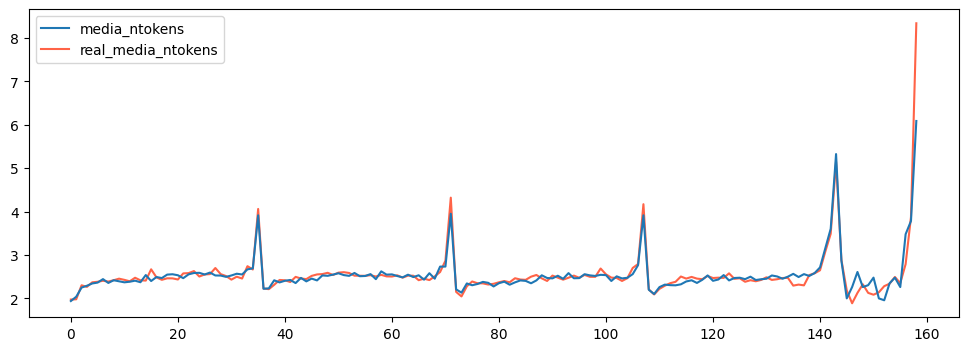

In [273]:
fig, ax = plt.subplots(1, 1, figsize = (12, 4))

df_\
.pipe(get_match_splits, num_secs = 200)\
.query("period <= 5")\
.astype({"keep_generating": "str"})\
.assign(kp_vector = lambda df: df.groupby(["sim_id", "period"])["keep_generating"].transform(lambda x: ", ".join(sorted(set(x)))))\
.assign(num_games = lambda df: df.groupby(["period"])["sim_id"].transform("nunique"))\
.groupby(["num_games", "period", "cat_time"], as_index = False, dropna = False, observed = True).size()\
.assign(media_ntokens = lambda df: df["size"] / df["num_games"])\
[["period", "cat_time", "media_ntokens"]]\
.sort_values(["period", "cat_time"], ascending = [True, False])\
.reset_index(drop = True)\
[["media_ntokens"]].plot(ax = ax)

dict_real_values["ntokens_20secs_strip"]\
.query("season == '201819'")\
.sort_values(["period", "cat_time"], ascending = [True, False])\
.reset_index(drop = True)\
[["real_media_ntokens"]].plot(ax = ax, color = "tomato", zorder = -3)

plt.show()

In [274]:
file = '../simulations/NGramModel_ExtraInfo_two_models/simulations_NGramModel_ExtraInfo_segregated_seasondata201819_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables1.parquet'

df_ = pd.read_parquet(file)
df_features_model = get_model_features(file)


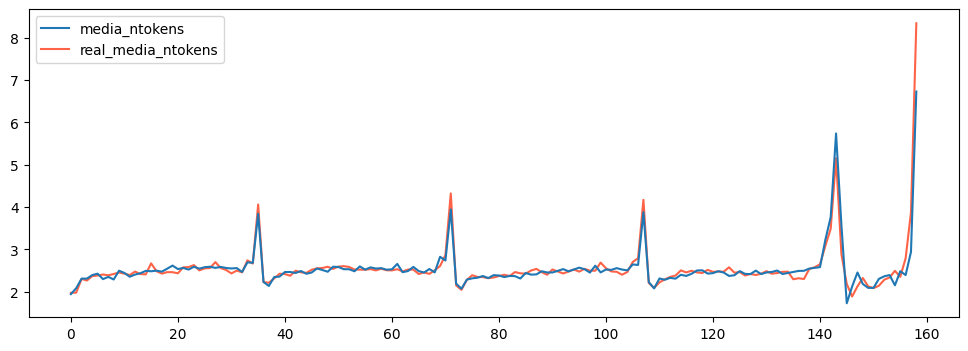

In [275]:
fig, ax = plt.subplots(1, 1, figsize = (12, 4))

df_\
.pipe(get_match_splits, num_secs = 200)\
.query("period <= 5")\
.astype({"keep_generating": "str"})\
.assign(kp_vector = lambda df: df.groupby(["sim_id", "period"])["keep_generating"].transform(lambda x: ", ".join(sorted(set(x)))))\
.assign(num_games = lambda df: df.groupby(["period"])["sim_id"].transform("nunique"))\
.groupby(["num_games", "period", "cat_time"], as_index = False, dropna = False, observed = True).size()\
.assign(media_ntokens = lambda df: df["size"] / df["num_games"])\
[["period", "cat_time", "media_ntokens"]]\
.sort_values(["period", "cat_time"], ascending = [True, False])\
.reset_index(drop = True)\
[["media_ntokens"]].plot(ax = ax)

dict_real_values["ntokens_20secs_strip"]\
.query("season == '201819'")\
.sort_values(["period", "cat_time"], ascending = [True, False])\
.reset_index(drop = True)\
[["real_media_ntokens"]].plot(ax = ax, color = "tomato", zorder = -3)

plt.show()

In [276]:

file = '../simulations/NGramModel_ExtraInfo_State/simulations_NGramModel_ExtraInfo_State_seasondata201819_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables1.parquet'

df_ = pd.read_parquet(file)
df_features_model = get_model_features(file)


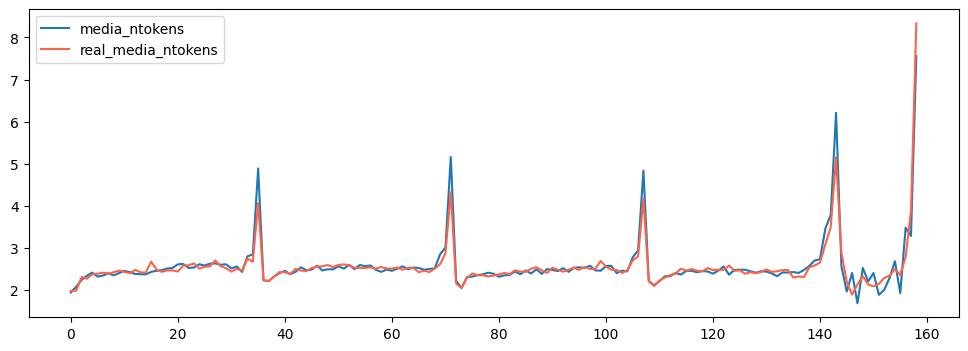

In [277]:
fig, ax = plt.subplots(1, 1, figsize = (12, 4))

df_\
.pipe(get_match_splits, num_secs = 200)\
.query("period <= 5")\
.astype({"keep_generating": "str"})\
.assign(kp_vector = lambda df: df.groupby(["sim_id", "period"])["keep_generating"].transform(lambda x: ", ".join(sorted(set(x)))))\
.assign(num_games = lambda df: df.groupby(["period"])["sim_id"].transform("nunique"))\
.groupby(["num_games", "period", "cat_time"], as_index = False, dropna = False, observed = True).size()\
.assign(media_ntokens = lambda df: df["size"] / df["num_games"])\
[["period", "cat_time", "media_ntokens"]]\
.sort_values(["period", "cat_time"], ascending = [True, False])\
.reset_index(drop = True)\
[["media_ntokens"]].plot(ax = ax)

dict_real_values["ntokens_20secs_strip"]\
.query("season == '201819'")\
.sort_values(["period", "cat_time"], ascending = [True, False])\
.reset_index(drop = True)\
[["real_media_ntokens"]].plot(ax = ax, color = "tomato", zorder = 3)

plt.show()

In [278]:
file = '../simulations/NGramModel_ExtraInfo_TimeDiffTower/simulations_NGramModel_ExtraInfo_TimeDiffTower_seasondata202021_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables56.parquet'

df_ = pd.read_parquet(file)
df_features_model = get_model_features(file)


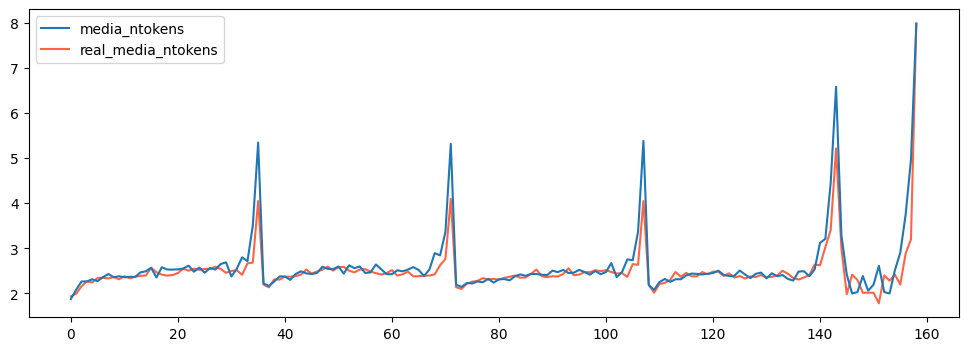

In [279]:
fig, ax = plt.subplots(1, 1, figsize = (12, 4))

df_\
.pipe(get_match_splits, num_secs = 200)\
.query("period <= 5")\
.astype({"keep_generating": "str"})\
.assign(kp_vector = lambda df: df.groupby(["sim_id", "period"])["keep_generating"].transform(lambda x: ", ".join(sorted(set(x)))))\
.assign(num_games = lambda df: df.groupby(["period"])["sim_id"].transform("nunique"))\
.groupby(["num_games", "period", "cat_time"], as_index = False, dropna = False, observed = True).size()\
.assign(media_ntokens = lambda df: df["size"] / df["num_games"])\
[["period", "cat_time", "media_ntokens"]]\
.sort_values(["period", "cat_time"], ascending = [True, False])\
.reset_index(drop = True)\
[["media_ntokens"]].plot(ax = ax)

dict_real_values["ntokens_20secs_strip"]\
.query("season == '202021'")\
.sort_values(["period", "cat_time"], ascending = [True, False])\
.reset_index(drop = True)\
[["real_media_ntokens"]].plot(ax = ax, color = "tomato", zorder = -3)

plt.show()

In [280]:
file = '../simulations/NGramModel_ExtraInfo_MultiTowers/simulations_NGramModel_ExtraInfo_MultiTowers_seasondata202223_context5_embedding64_numlayers5_numneurons50_dropout03_layernormTrue_setcovariables56.parquet'

df_ = pd.read_parquet(file)
df_features_model = get_model_features(file)


In [269]:
integer_to_token[85]

'p000_12(1)'

In [268]:
df_.query("sim_id == 893 & period == 1")

,sim_id,step,period,remaining_time,token,prob,time,home_points,away_points,limhteam,limvteam,limhtimeout,limvtimeout,ball_possession,keep_generating
314848,893,0,1,7200,85,0.019448,0,0,0,4,4,7,7,0,1
314849,893,1,1,7200,523,0.017990,0,0,0,4,4,7,7,0,1
314850,893,2,1,0,85,0.063029,7200,0,0,1,1,7,7,0,2


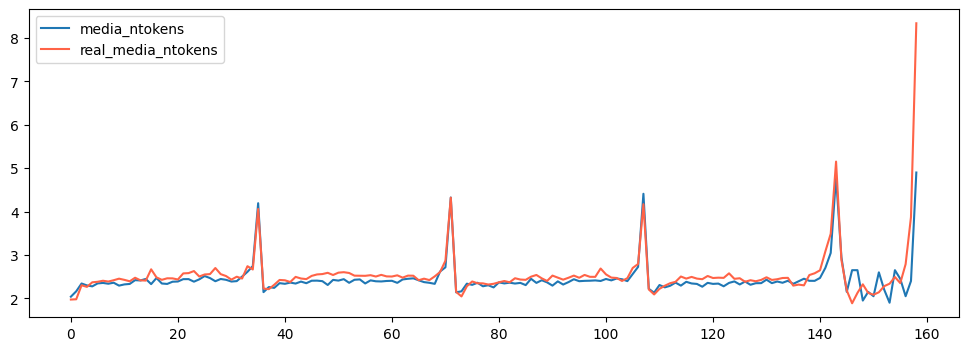

In [281]:
fig, ax = plt.subplots(1, 1, figsize = (12, 4))

df_\
.pipe(get_match_splits, num_secs = 200)\
.query("period <= 5")\
.astype({"keep_generating": "str"})\
.assign(kp_vector = lambda df: df.groupby(["sim_id", "period"])["keep_generating"].transform(lambda x: ", ".join(sorted(set(x)))))\
.assign(num_games = lambda df: df.groupby(["period"])["sim_id"].transform("nunique"))\
.groupby(["num_games", "period", "cat_time"], as_index = False, dropna = False, observed = True).size()\
.assign(media_ntokens = lambda df: df["size"] / df["num_games"])\
[["period", "cat_time", "media_ntokens"]]\
.sort_values(["period", "cat_time"], ascending = [True, False])\
.reset_index(drop = True)\
[["media_ntokens"]].plot(ax = ax)

dict_real_values["ntokens_20secs_strip"]\
.query("season == '201819'")\
.sort_values(["period", "cat_time"], ascending = [True, False])\
.reset_index(drop = True)\
[["real_media_ntokens"]].plot(ax = ax, color = "tomato", zorder = 3)

plt.show()

In [ ]:
# Grupo 1: Resultados e Estatísticas Gerais
# E1: Diferença das proporções de resultados ao fim do 4º período (Mandante, Visitante e Overtime).
# E2: Descritivas (Média e DP) de Pontos do Mandante.
# E3: Descritivas (Média e DP) de Pontos do Visitante. (Inserido aqui para parear com E2).
# E4: Descritivas (Média e DP) da Quantidade de Tokens por período (Pace).
# E5: WD de Pontos do Mandante ao fim do 4º período.
# E6: WD de Pontos do Visitante ao fim do 4º período.
# E7: WD da Diferença de Pontos (Spread) ao fim do 4º período.

# Grupo 2: Dinâmica de Urgência (Taxa de Pontuação por Contexto)
# E8: Comparação de distribuição (WD) da Taxa de Urgência do Mandante (considerando o jogo inteiro em bins de tempo e placar).
# E9: Comparação de distribuição (WD) da Taxa de Urgência do Visitante (considerando o jogo inteiro).
# E10: Comparação de distribuição (WD) da Taxa de Urgência do Mandante (apenas nos 2 minutos finais).
# E11: Comparação de distribuição (WD) da Taxa de Urgência do Visitante (apenas nos 2 minutos finais).

# Grupo 3: Evolução Temporal (Séries Temporais)
# E12: Comparação de distribuição (WD) da Média de pontos por segundo do Mandante (curva de progressão).
# E13: Comparação de distribuição (WD) da Média de pontos por segundo do Visitante.

# Grupo 4: Ritmo por Período (Volume de Jogadas)
# E14: Comparação de distribuição (WD) do número de tokens no 1º Período.
# E15: Comparação de distribuição (WD) do número de tokens no 2º Período.
# E16: Comparação de distribuição (WD) do número de tokens no 3º Período.
# E17: Comparação de distribuição (WD) do número de tokens no 4º Período.
# E18: Comparação de distribuição (WD) do número de tokens no Overtime.

# E19: diferença das proporções dos tipos de token
